# Project: 멋진 챗봇 만들기
라이브러리 버전을 확인해 봅니다

사용할 라이브러리 버전을 둘러봅시다.

In [1]:
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

1.23.5
2.3.3
2.10.0+cu128
3.9.4
4.4.0


지난 노드에서 챗봇과 번역기는 같은 집안이라고 했던 말을 기억하시나요? 

앞서 배운 Seq2seq번역기와 Transfomer번역기에 적용할 수도 있겠지만, 이번 노드에서 배운 번역기 성능 측정법을 챗봇에도 적용해 봅시다. 배운 지식을 다양하게 활용할 수 있는 것도 중요한 능력이겠죠. 이번 프로젝트를 통해서 챗봇과 번역기가 같은 집안인지 확인해 보세요!

### Step 1. 데이터 다운로드 (완료)

준비하기 단계에서 심볼릭 링크를 생성했다면 아래 파일이 ChatbotData.csv라는 이름으로 저장되어 있을거예요. csv 파일을 읽는 데에는 pandas 라이브러리가 적합합니다. 읽어 온 데이터의 질문과 답변을 각각 questions, answers 변수에 나눠서 저장하세요!

In [2]:
import pandas as pd

# CSV 파일을 DataFrame으로 로드 (변수명을 df로 지정)
df = pd.read_csv('./project_data/ChatbotData.csv')

# 확인
print(df.shape)   # (11823, 3)
print(df.head())


(11823, 3)
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0


### Step 2. 데이터 정제
아래 조건을 만족하는 preprocess_sentence() 함수를 구현하세요.


영문자의 경우, 모두 소문자로 변환합니다.
영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하곤 정규식을 활용하여 모두 제거합니다.

문장부호 양옆에 공백을 추가하는 등 이전과 다르게 생략된 기능들은 우리가 사용할 토크나이저가 지원하기 때문에 굳이 구현하지 않아도 괜찮습니다!

In [3]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower()  # 대문자를 소문자로 변환
    # 영문자, 한글(자모 포함), 숫자, 주요 문장부호(?.!,)를 제외한 문자는 공백으로 치환
    sentence = re.sub(r"[^a-zA-Z0-9가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
    sentence = re.sub(r" {2,}", " ", sentence)  # 연속 공백을 하나로
    sentence = sentence.strip()  # 양 끝 공백 제거
    return sentence

In [4]:
questions = list(map(preprocess_sentence, df['Q'].tolist()))
answers   = list(map(preprocess_sentence, df['A'].tolist()))

In [5]:
len(questions), len(answers)

(11823, 11823)

In [6]:
print(questions[:5])
print(answers[:5])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네']
['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.', '여행은 언제나 좋죠.', '눈살이 찌푸려지죠.']


### Step 3. 데이터 토큰화

토큰화에는 KoNLPy의 mecab 클래스를 사용합니다. 

아래 조건을 만족하는 build_corpus() 함수를 구현하세요!

1. 소스 문장 데이터와 타겟 문장 데이터를 입력으로 받습니다.
2. 데이터를 앞서 정의한 preprocess_sentence() 함수로 정제하고, 토큰화합니다.
3. 토큰화는 전달받은 토크나이즈 함수를 사용합니다. 이번엔 mecab.morphs 함수를 전달하시면 됩니다.
4. 토큰의 개수가 일정 길이 이상인 문장은 데이터에서 제외합니다.
5. 중복되는 문장은 데이터에서 제외합니다. 소스 : 타겟 쌍을 비교하지 않고 소스는 소스대로 타겟은 타겟대로 검사합니다. 중복 쌍이 흐트러지지 않도록 유의하세요!

구현한 함수를 활용하여 questions 와 answers 를 각각 que_corpus , ans_corpus 에 토큰화하여 저장합니다.

In [7]:
import re

def preprocess_sentence(sentence: str) -> str:
    sentence = sentence.lower()
    # 영문/숫자/한글(자모 포함)/주요 문장부호만 남김
    sentence = re.sub(r"[^a-zA-Z0-9가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

questions = list(map(preprocess_sentence, df['Q'].tolist()))
answers   = list(map(preprocess_sentence, df['A'].tolist()))

In [8]:
import sentencepiece as spm

VOCAB_SIZE = 8000

def generate_tokenizer(corpus, vocab_size, prefix,
                      pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    txt_path = f"./{prefix}_corpus.txt"
    model_prefix = f"./{prefix}_spm"
    with open(txt_path, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(row + "\n")

    spm.SentencePieceTrainer.Train(
        f"--input={txt_path} --model_prefix={model_prefix} "
        f"--vocab_size={vocab_size} --character_coverage=0.9995 "
        f"--model_type=bpe "
        f"--pad_id={pad_id} --bos_id={bos_id} --eos_id={eos_id} --unk_id={unk_id}"
    )
    tk = spm.SentencePieceProcessor()
    tk.Load(f"{model_prefix}.model")
    return tk

# Q + A를 합쳐서 하나의 토크나이저 학습
print("토크나이저 학습 중...")
tokenizer = generate_tokenizer(questions + answers, VOCAB_SIZE, "chatbot")

PAD_ID, BOS_ID, EOS_ID, UNK_ID = 0, 1, 2, 3
print(f"Vocab size: {tokenizer.get_piece_size()}")
print(f"샘플: {tokenizer.encode_as_pieces('안녕하세요 반갑습니다')}")

토크나이저 학습 중...
Vocab size: 8000
샘플: ['▁안녕하세요', '▁반갑', '습니다']


In [9]:
def build_corpus(src_sentences, tgt_sentences, tokenize_fn, max_len=40):
    """
    - 전처리 + 토큰화
    - max_len 초과 토큰 쌍 제외
    - 소스/타겟 각각 중복 검사 (쌍 정렬은 유지)
    """
    assert len(src_sentences) == len(tgt_sentences)

    src_corpus, tgt_corpus = [], []
    seen_src, seen_tgt = set(), set()

    for src, tgt in zip(src_sentences, tgt_sentences):
        # 1) 전처리
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)

        # 2) 중복 검사 (소스 또는 타겟 중 하나라도 봤다면 쌍 통째 스킵)
        if src_clean in seen_src or tgt_clean in seen_tgt:
            continue

        # 3) 토큰화
        src_tokens = tokenize_fn(src_clean)
        tgt_tokens = tokenize_fn(tgt_clean)

        # 4) 길이 필터
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)
        seen_src.add(src_clean)
        seen_tgt.add(tgt_clean)

    return src_corpus, tgt_corpus

In [10]:
# 원본 df['Q'], df['A']를 그대로 넣어도 build_corpus가 전처리해줌
que_corpus, ans_corpus = build_corpus(
    df['Q'].tolist(),
    df['A'].tolist(),
    tokenizer.encode_as_pieces,   # ← mecab.morphs 자리에 이게 들어감
    max_len=40
)

print(f"전체 쌍: {len(que_corpus)}")
for i in range(3):
    print(f"Q: {que_corpus[i]}")
    print(f"A: {ans_corpus[i]}\n")

전체 쌍: 7739
Q: ['▁12', '시', '▁땡', '!']
A: ['▁하루가', '▁또', '▁가네요', '.']

Q: ['▁1', '지', '망', '▁학교', '▁떨어졌어']
A: ['▁위로해', '▁드립니다', '.']

Q: ['▁3', '박', '4', '일', '▁놀러가고', '▁싶다']
A: ['▁여행은', '▁언제나', '▁좋죠', '.']



### Step 4. Augmentation
우리에게 주어진 데이터는 1만 개가량으로 적은 편에 속합니다. 이럴 때에 사용할 수 있는 테크닉을 배웠으니 활용해 봐야겠죠? Lexical Substitution을 실제로 적용해 보도록 하겠습니다. 

아래 링크를 참고하여 한국어로 사전 훈련된 Embedding 모델을 다운로드합니다. Korean (w) 가 Word2Vec으로 학습한 모델이며 용량도 적당하므로 사이트에서 Korean (w)를 찾아 다운로드하고, ko.bin 파일을 얻으세요!

다운로드한 모델을 활용해 데이터를 Augmentation 하세요! 앞서 정의한 lexical_sub() 함수를 참고하면 도움이 많이 될 겁니다. 

Augmentation된 que_corpus 와 원본 ans_corpus 가 병렬을 이루도록, 이후엔 반대로 원본 que_corpus 와 Augmentation된 ans_corpus 가 병렬을 이루도록 하여 전체 데이터가 원래의 3배가량으로 늘어나도록 합니다.

### --------
https://github.com/Kyubyong/wordvectors 링크에서 아래 스크롤내리면 korean(w) 링크에있는 파일 다운받기

https://github.com/Kyubyong/wordvectors/blob/master/make_wordvectors.py 파이썬 예제

gensim 설치

uv pip install gensim

uv pip install "gensim<4.0"


In [ ]:
# from gensim.models import Word2Vec

# w2v = Word2Vec.load('./project_data/ko.bin')

# # 동작 확인
# print(w2v.wv.most_similar('학교', topn=5))
# # [('고등학교', 0.83), ('대학교', 0.79), ('중학교', 0.77), ...]

# print(f"어휘 크기: {len(w2v.wv.key_to_index):,}")
# print(f"벡터 차원: {w2v.wv.vector_size}")

#from gensim.models import Word2Vec
#w2v = Word2Vec.load('./project_data/ko.bin')

# 주의: gensim 3.x에선 model 자체에서 most_similar 호출 가능
#print(w2v.most_similar('학교', topn=5))    # 3.x 방식
#print(w2v.wv.most_similar('학교', topn=5)) # 둘 다 동작

UnpicklingError: invalid load key, '\xc8'.

### Gensim은 호환성문제가있음. 
#### 파이썬 3.9이하여야하고 numpy버전때문에 설치에러남.

### So, FastText 사용 (Gensim도 다시 4.x 최신버전으로 교체) 한글 데이터도 Korean (f) 로 다시 다운받기

In [ ]:
#from gensim.models.fasttext import load_facebook_vectors

#ft = load_facebook_vectors('./project_data/ko.bin')      # ← 1.6기가 데이터 fastText 데이터지만 gensim 활용


# 동작 확인
#print(ft.most_similar('학교', topn=5))
#print(f"벡터 차원: {ft.vector_size}")

[('전문학교', 0.7264527082443237), ('대학', 0.7240150570869446), ('중학교', 0.7209151983261108), ('연세대', 0.685256838798523), ('중고등학교', 0.6829690933227539)]
벡터 차원: 200


### Fasttext 자체 라이브러리 사용

ft = load_facebook_vectors('./project_data/cc.ko.300.bin.bin')    # 7.0기가 데이터

사용하려고 했더니 gensim 4.0에서 에러남.

#### 설치 필요
uv pip install fasttext-wheel

In [13]:
import fasttext

ft = fasttext.load_model('./project_data/cc.ko.300.bin')

# 유사 단어
print(ft.get_nearest_neighbors('학교', k=5))

[(0.6481001377105713, '學校'), (0.6070489287376404, '기숙'), (0.5820465683937073, '학원'), (0.5783581733703613, '학교나'), (0.5667772889137268, '대학')]


### lexical_sub() 거의 동일
API가 같고, FastText는 OOV 단어도 character n-gram으로 처리 가능해서 Word2Vec보다 오히려 좋다고함.

### lexical_sub() Mecab 활용버전

In [14]:
import random

def lexical_sub(sentence: str, ft_model, mecab, prob=0.3, top_n=5) -> str:
    tokens = mecab.morphs(sentence)
    new_tokens = []
    for tok in tokens:
        try:
            if random.random() < prob:
                # Gensim 4.0 fasttext 모델 사용법
                # similars = ft_model.most_similar(tok, topn=top_n)
                # new_tokens.append(random.choice(similars)[0])
                
                # fasttext-wheel, fasttext 모델 사용법
                similars = ft_model.get_nearest_neighbors(tok, k=top_n)
                new_tok = random.choice(similars)[1]   # (score, word) 튜플이라 [1] 사용
                new_tokens.append(new_tok)
            else:
                new_tokens.append(tok)
        except KeyError:
            new_tokens.append(tok)
    return ' '.join(new_tokens)

### lexical_sub() 형태소 분석기 없이 띄어쓰리고 구분

In [15]:
def lexical_sub(sentence: str, ft_model, prob=0.3, top_n=5) -> str:
    """공백 단위로 분리 → 일부 단어를 FastText 유사어로 치환"""
    tokens = sentence.split()
    new_tokens = []
    for tok in tokens:
        if random.random() < prob:
            try:
                similars = ft_model.get_nearest_neighbors(tok, k=top_n)
                if similars:
                    new_tokens.append(random.choice(similars)[1])
                    continue
            except Exception:
                pass
        new_tokens.append(tok)
    return ' '.join(new_tokens)

In [16]:
# 동작 테스트
test_sentence = "학교에 가기 싫어"
print(f"\n원본: {test_sentence}")
for i in range(3):
    print(f"증강 {i+1}: {lexical_sub(test_sentence, ft, prob=0.5)}")


원본: 학교에 가기 싫어
증강 1: 학교에 보러 싫은
증강 2: 학교에 가기 싫어
증강 3: 학교에서 歌妓 좋아


### 띄어쓰기로 사용 못함.

### lexical_sub() Sentence Piece 활용버전

In [17]:
import random

def lexical_sub(sentence: str, ft, mecab, prob=0.3, top_n=10, sim_threshold=0.6) -> str:
    tokens = mecab.morphs(sentence)
    new_tokens = []
    
    for tok in tokens:
        substituted = False
        if random.random() < prob:
            try:
                similars = ft.most_similar(tok, topn=top_n)
                # 필터링: ▁ 없는, 한글로만 된, 유사도 충분히 높은 것만
                candidates = [
                    w for w, sim in similars
                    if '▁' not in w
                    and w != tok
                    and sim >= sim_threshold
                    and all('가' <= ch <= '힣' for ch in w)  # 순수 한글만
                ]
                if candidates:
                    new_tokens.append(random.choice(candidates))
                    substituted = True
            except KeyError:
                pass
        if not substituted:
            new_tokens.append(tok)
    
    return ' '.join(new_tokens)

### 토크나이저 작동 확인

In [18]:
test = "학교 에 가기 싫어, 오늘 날씨 너무 좋다"
pieces = tokenizer.encode_as_pieces(test)
print(pieces)

['▁학교', '▁에', '▁가기', '▁싫어', ',', '▁오늘', '▁날씨', '▁너무', '▁좋다']


In [ ]:
# 순서 꼬여서 주석처리 중요한것아님.

# 동작 확인 
#test_sentences = [
    #"사랑해요 진짜 좋아해요",
#]
#for s in test_sentences:
    #print(f"\n원본: {s}")
    #for i in range(3):
        #print(f"증강 {i+1}: {lexical_sub(s, ft, tokenizer, prob=0.5)}")


원본: 사랑해요 진짜 좋아해요


AttributeError: 'SentencePieceProcessor' object has no attribute 'morphs'

### Mecab 윈도우에 설치

In [ ]:
# 이것도 주피터에서 안될듯 로컬에 수동설치한경우에만 실행가능

import subprocess

result = subprocess.run(
    ["mecab"],
    input="안녕하세요\n",
    text=True,
    capture_output=True
)

print(result.stdout)

안녕	NNG,행위,T,안녕,*,*,*,*
하	XSV,*,F,하,*,*,*,*
세요	EP+EF,*,F,세요,Inflect,EP,EF,시/EP/*+어요/EF/*
EOS



In [21]:
import shutil

print(shutil.which("mecab"))

c:\mecab\bin\mecab.EXE


In [22]:
import mecab
mecab = mecab.MeCab()

print(mecab.morphs("안녕하세요"))

['안녕', '하', '세요']


### 이거 mecab ko 설치할때 기존 mecab 지우고 해야됨.

### 형태소 분석기 작동 확인

In [23]:
from mecab import MeCab

mecab = MeCab()

# 동작 확인
print(mecab.morphs("안녕하세요 반갑습니다"))
# ['안녕', '하', '세요', '반갑', '습니다']

print(mecab.pos("안녕하세요 반갑습니다"))
# [('안녕', 'NNG'), ('하', 'XSV'), ('세요', 'EP+EF'), ...]

print(mecab.nouns("자연어 처리는 재미있는 분야입니다"))
# ['자연어', '처리', '분야']

['안녕', '하', '세요', '반갑', '습니다']
[('안녕', 'NNG'), ('하', 'XSV'), ('세요', 'EP+EF'), ('반갑', 'VA'), ('습니다', 'EF')]
['자연어', '처리', '분야']


In [ ]:
# mecab 사용해서 lexical_sub 함수 테스트

#test_sentences = [
    #"사랑해요 진짜 좋아해요",
#]
#for s in test_sentences:
    #print(f"\n원본: {s}")
    #for i in range(3):
        #print(f"증강 {i+1}: {lexical_sub(s, ft, mecab, prob=0.5)}")


원본: 사랑해요 진짜 좋아해요


AttributeError: '_FastText' object has no attribute 'most_similar'

In [ ]:
# mecab 사용해서 lexical_sub 함수 테스트

#test_sentences = [
    #"그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다",
#]
#for s in test_sentences:
#    print(f"\n원본: {s}")
    #for i in range(3):
        #print(f"증강 {i+1}: {lexical_sub(s, ft, mecab, prob=0.5)}")


원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다


AttributeError: '_FastText' object has no attribute 'most_similar'

### 현재 데이터 증강이 제대로 안됌. 방법을 수정해야함.

In [26]:
import random

CONTENT_TAGS = {'NNG', 'NNP', 'VV', 'VA', 'MAG'}

def lexical_sub(sentence: str, ft, mecab, prob=0.3, top_n=10, sim_threshold=0.6) -> str:
    pos_tokens = mecab.pos(sentence)
    
    new_tokens = []
    for tok, tag in pos_tokens:
        substituted = False
        if tag in CONTENT_TAGS and random.random() < prob:
            # fasttext: [(sim, word), ...] 순서 주의!
            similars = ft.get_nearest_neighbors(tok, k=top_n)
            candidates = [
                w for sim, w in similars                # ← 언패킹 순서 반대
                if '▁' not in w
                and w != tok
                and sim >= sim_threshold
                and all('가' <= ch <= '힣' for ch in w)
                and len(w) >= 2
            ]
            if candidates:
                new_tokens.append(random.choice(candidates))
                substituted = True
        if not substituted:
            new_tokens.append(tok)
    
    return ' '.join(new_tokens)

In [27]:
# mecab 사용해서 lexical_sub 함수 테스트

test_sentences = [
    "사랑해요 진짜 좋아해요",
]
for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab, prob=0.5)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 세상끝의 해요 진짜 편하 아 해요
증강 2: 세상끝의 해요 정말 편하 아 해요
증강 3: 세상끝의 해요 진짜 좋 아 해요


In [28]:
# mecab 사용해서 lexical_sub 함수 테스트

test_sentences = [
    "그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다",
]
for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab, prob=0.5)}")


원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀 러 가 면 되 나요 ? 단체기관 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다
증강 2: 그래서 폭발할지 놀 러 가 면 되 나요 ? 단체 로 가 서 술도 마시 면 으면 겠 네요 어지르 고 싶 다
증강 3: 그래서 언제 놀 러 가 면 되 나요 ? 단체기관 로 가 서 술도 마시 면 되 겠 네요 어지르 고 싶 다


#### 왜 이런 결과가 나오나
FastText 모델(Kyubyong 또는 cc.ko.300)이 위키피디아로 학습돼서 "파시냐노"(이탈리아 와인) 같은 희귀 단어들이 어휘에 있어요. 게다가 character n-gram 기반이라 글자 모양이 비슷하면 의미와 무관하게 가까운 이웃으로 잡힙니다.
개선책
#### 1) 유사도 임계값 올리기
가장 효과적이에요. 0.7 이상으로 올리면 "세상끝의", "파시냐노" 같은 노이즈가 대거 사라집니다:

top_n도 10→15로 늘려서 필터링 후에도 후보가 남도록.
#### 2) 의문사 보호
의문사가 치환되면 문장 의미가 통째로 바뀌어요. 의문사 목록 만들어서 제외:

In [29]:
import random

CONTENT_TAGS = {'NNG', 'NNP', 'VV', 'VA', 'MAG'}
PROTECT_WORDS = {'언제', '어디', '누구', '왜', '뭐', '무엇', '어떻게', '어느', '얼마'}

def lexical_sub(sentence, ft, mecab, prob=0.3, top_n=15, sim_threshold=0.75):
    pos_tokens = mecab.pos(sentence)
    new_tokens = []
    for tok, tag in pos_tokens:
        substituted = False
        if tag in CONTENT_TAGS and tok not in PROTECT_WORDS and random.random() < prob:
            similars = ft.get_nearest_neighbors(tok, k=top_n)
            candidates = [
                w for sim, w in similars
                if '▁' not in w
                and w != tok
                and sim >= sim_threshold
                and all('가' <= ch <= '힣' for ch in w)
                and 2 <= len(w) <= len(tok) + 2   # ← 길이 차 제한 추가
            ]
            if candidates:
                new_tokens.append(random.choice(candidates))
                substituted = True
        if not substituted:
            new_tokens.append(tok)
    return ' '.join(new_tokens)

In [30]:
# mecab 사용해서 lexical_sub 함수 테스트

test_sentences = [
    "사랑해요 진짜 좋아해요",
]
for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab, prob=0.5)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 사랑 해요 진짜 좋 아 해요
증강 2: 사랑 해요 진짜 좋 아 해요
증강 3: 사랑 해요 진짜 좋 아 해요


In [31]:
# mecab 사용해서 lexical_sub 함수 테스트

test_sentences = [
    "그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다",
]
for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab, prob=0.5)}")


원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다
증강 2: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다
증강 3: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다


#### 치환 0 문제 발생함 

진단: 후보가 실제로 뭐가 있는지 보기

먼저 디버깅 코드로 어떤 후보들이 잡히고 왜 다 걸러지는지 확인합시다:

In [32]:
def debug_neighbors(word, ft, top_n=15):
    print(f"\n=== '{word}' 의 이웃 ===")
    for sim, w in ft.get_nearest_neighbors(word, k=top_n):
        flags = []
        if '▁' in w: flags.append('SP마커')
        if not all('가' <= ch <= '힣' for ch in w): flags.append('비한글')
        if len(w) < 2: flags.append('짧음')
        if len(w) > len(word) + 2: flags.append('너무김')
        if sim < 0.75: flags.append('유사도낮음')
        flag_str = f"  [걸림: {','.join(flags)}]" if flags else "  ✅ 통과"
        print(f"  {sim:.3f}  {w:<10}{flag_str}")

debug_neighbors('사랑', ft)
debug_neighbors('진짜', ft)
debug_neighbors('좋', ft)
debug_neighbors('그래서', ft)
debug_neighbors('언제', ft)
debug_neighbors('단체로', ft)
debug_neighbors('술마시면', ft)
debug_neighbors('되겠네요', ft)
debug_neighbors('어지르고싶다', ft)


=== '사랑' 의 이웃 ===
  0.616  세상끝의        [걸림: 유사도낮음]
  0.607  lelu        [걸림: 비한글,유사도낮음]
  0.583  몰래한         [걸림: 유사도낮음]
  0.581  사랑을         [걸림: 유사도낮음]
  0.571  한에스더        [걸림: 유사도낮음]
  0.564  比目魚         [걸림: 비한글,유사도낮음]
  0.558  영국고객        [걸림: 유사도낮음]
  0.551  恋           [걸림: 비한글,짧음,유사도낮음]
  0.542  이깟          [걸림: 유사도낮음]
  0.540  함께2-최고의     [걸림: 비한글,너무김,유사도낮음]
  0.535  연민          [걸림: 유사도낮음]
  0.531  궁정식         [걸림: 유사도낮음]
  0.529  달자씨         [걸림: 유사도낮음]
  0.529  구애정         [걸림: 유사도낮음]
  0.528  서버확장        [걸림: 유사도낮음]

=== '진짜' 의 이웃 ===
  0.601  정말          [걸림: 유사도낮음]
  0.556  ㄹㅇ          [걸림: 비한글,유사도낮음]
  0.544  서울시예산       [걸림: 너무김,유사도낮음]
  0.538  시끄럽네        [걸림: 유사도낮음]
  0.534  증말          [걸림: 유사도낮음]
  0.531  실험쇼         [걸림: 유사도낮음]
  0.529  완젼          [걸림: 유사도낮음]
  0.525  취저          [걸림: 유사도낮음]
  0.522  모냐          [걸림: 유사도낮음]
  0.522  웃김          [걸림: 유사도낮음]
  0.519  얘네          [걸림: 유사도낮음]
  0.517  이게          [걸림: 유사도낮음]
  0.517  쩐다          [걸림: 유사도낮음]
  0.516

## 분석

기존 임계값 0.6 -> 엉터리 증강발생

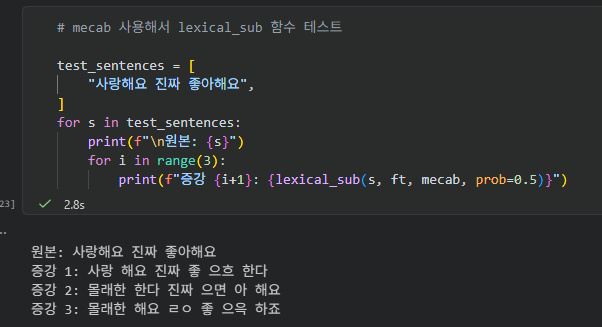

수정 임계값 0.75 -> 같은내용이라 증강 안됨

단어를 여러개 추가해봐도 0.7이상주면 증강안되는게맞는거같고 0.6이면 쓰레기값들로 증강이됨..

### lexical_sub 함수 단순화 시도


In [33]:
import random

def lexical_sub(sentence, ft):
    # 1. 문장을 토큰화 (공백 단위)
    tokens = sentence.split()
    
    if not tokens:
        return sentence
    
    # 2. 무작위로 한 단어 선택
    selected_tok = random.choice(tokens)
    
    # 3. 가장 유사한 단어 찾기
    #    fasttext는 [(유사도, 단어), ...] 순서로 반환
    similar_word = ft.get_nearest_neighbors(selected_tok, k=1)[0][1]
    
    # 4. 변환된 문장 생성
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])
    return new_sentence

In [34]:
test_sentences = [
    "사랑해요 진짜 좋아해요",
    "그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다",
]
for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft)}")        


원본: 사랑해요 진짜 좋아해요
증강 1: 사랑해요 정말 좋아해요
증강 2: 사랑해요 진짜 좋아합니다
증강 3: 사랑해요 정말 좋아해요

원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 ---한식회.일식.양식베이커리.떡집.햄버거배달전문.중화요리카페.주점.노래방레저.숙박운송.정비농축수산물.꽃배달.유통교육.학원의료.건강.미용.스포츠패션.잡화건축.토목.설비관련금융.법무.세무컴퓨터.IT렌트.임대가전.가구생활서비스.광고대포농공단지여행정보부동산취업
증강 2: 그래서 언제 놀러가면 되나요? 단체가 가서 술마시면 되겠네요 어지르고싶다
증강 3: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 ---한식회.일식.양식베이커리.떡집.햄버거배달전문.중화요리카페.주점.노래방레저.숙박운송.정비농축수산물.꽃배달.유통교육.학원의료.건강.미용.스포츠패션.잡화건축.토목.설비관련금융.법무.세무컴퓨터.IT렌트.임대가전.가구생활서비스.광고대포농공단지여행정보부동산취업


### 버전 2: Mecab 토큰화 (의미 단위 분리)

In [35]:
import random

def lexical_sub(sentence, ft, mecab):
    # 1. mecab으로 형태소 분석
    tokens = mecab.morphs(sentence)
    
    if not tokens:
        return sentence
    
    # 2. 무작위 토큰 선택
    selected_tok = random.choice(tokens)
    
    # 3. 가장 유사한 단어
    similar_word = ft.get_nearest_neighbors(selected_tok, k=1)[0][1]
    
    # 4. 새 문장 생성
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])
    return new_sentence

In [36]:
test_sentences = [
    "사랑해요 진짜 좋아해요",
    "그래서 언제 놀러가면 되나요",
]

for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab)}")
        # mecab 버전: print(f"증강 {i+1}: {lexical_sub(s, ft, mecab)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 세상끝의 해요 진짜 좋 아 해요
증강 2: 사랑 하죠 진짜 좋 아 하죠
증강 3: 사랑 하죠 진짜 좋 아 하죠

원본: 그래서 언제 놀러가면 되나요
증강 1: 그래서 잘릴지 놀 러 가 면 되 나요
증강 2: 그래서 언제 놀 러 와 면 되 나요
증강 3: 그래서 언제 놀 러 가 免 되 나요


## 증강데이터 자체가 안좋은거같음...

In [37]:
# 1.6기가모델 or 7기가모델중 안써본 다른하나로 해보려는데 둘다 cell number가 18 커널재시작하면서 꼬임.. 둘다 다시확인

import fasttext

ft = fasttext.load_model('./project_data/cc.ko.300.bin')  # 7기가모델 재로드   

# 유사 단어
print(ft.get_nearest_neighbors('학교', k=5))

[(0.6481001377105713, '學校'), (0.6070489287376404, '기숙'), (0.5820465683937073, '학원'), (0.5783581733703613, '학교나'), (0.5667772889137268, '대학')]


In [38]:
test_sentences = [
    "사랑해요 진짜 좋아해요",
    "그래서 언제 놀러가면 되나요",
]

for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab)}")
        # mecab 버전: print(f"증강 {i+1}: {lexical_sub(s, ft, mecab)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 세상끝의 해요 진짜 좋 아 해요
증강 2: 사랑 해요 정말 좋 아 해요
증강 3: 사랑 해요 진짜 편하 아 해요

원본: 그래서 언제 놀러가면 되나요
증강 1: 그래서 언제 르시 러 가 면 되 나요
증강 2: 그래서 언제 놀 러 가 면 되 나죠
증강 3: 그런데 언제 놀 러 가 면 되 나요


결과 보니까 지금까지 7기가 증강데이터로 해본거같음.

In [39]:
from gensim.models.fasttext import load_facebook_vectors

ft = load_facebook_vectors('./project_data/ko.bin')      # ← 1.6기가 데이터 fastText 데이터지만 gensim 활용


# 동작 확인
print(ft.most_similar('학교', topn=5))
print(f"벡터 차원: {ft.vector_size}")

[('전문학교', 0.7264527082443237), ('대학', 0.7240150570869446), ('중학교', 0.7209151983261108), ('연세대', 0.685256838798523), ('중고등학교', 0.6829690933227539)]
벡터 차원: 200


### 공식 FastText 말고 gensim의 fasttext 모델(?)로 Lexical Sub 함수 재정의

In [40]:
import random

def lexical_sub(sentence, ft):
    tokens = sentence.split()
    if not tokens:
        return sentence
    
    selected_tok = random.choice(tokens)
    
    # gensim: [(단어, 유사도), ...] 순서
    similar_word = ft.most_similar(selected_tok, topn=1)[0][0]
    
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])
    return new_sentence

In [41]:
test_sentences = [
    "사랑해요 진짜 좋아해요",
    "그래서 언제 놀러가면 되나요",
]

for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft)}")
        # mecab 버전: print(f"증강 {i+1}: {lexical_sub(s, ft, mecab)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 사랑해요 진짜 좋아지
증강 2: 사랑해요 진짜 좋아지
증강 3: 사랑해요 가짜 좋아해요

원본: 그래서 언제 놀러가면 되나요
증강 1: 그래서 어디 놀러가면 되나요
증강 2: 하지만 언제 놀러가면 되나요
증강 3: 그래서 언제 가면 되나요


In [42]:
import random
import re

def lexical_sub(sentence, ft):
    tokens = sentence.split()
    if not tokens:
        return sentence
    
    selected_tok = random.choice(tokens)
    
    # 구두점 분리 (?, !, . 가 붙으면 매칭 망가짐)
    clean_tok = re.sub(r'[?.!,]', '', selected_tok)
    if not clean_tok:
        return sentence
    
    # gensim: [(단어, 유사도), ...] 순서
    try:
        candidates = ft.most_similar(clean_tok, topn=5)
    except KeyError:
        return sentence
    
    similar_word = None
    for w, sim in candidates:                          # ← 순서 (단어, 유사도)
        if (len(w) <= len(clean_tok) + 3
            and 1 <= len(w) <= 10
            and all('가' <= ch <= '힣' for ch in w)   # 순수 한글만
            and w != clean_tok):
            similar_word = w
            break
    
    if similar_word is None:
        return sentence
    
    # 구두점 복원
    punct = re.findall(r'[?.!,]+$', selected_tok)
    if punct:
        similar_word = similar_word + punct[0]
    
    new_sentence = " ".join([similar_word if tok == selected_tok else tok for tok in tokens])
    return new_sentence

In [43]:
test_sentences = [
    "사랑해요 진짜 좋아해요",
    "그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다",
]

for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 사랑해요 진짜 좋아지
증강 2: 사랑해요 진짜 좋아지
증강 3: 사랑해요 진짜 좋아지

원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀러가면 나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 2: 그래서 언제 가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 3: 그래서 언제 놀러가면 되나요? 단체로 나아가서 술마시면 되겠네요 어지르고싶다


## 1) 유연한 lexical_sub (Mecab + gensim)

In [44]:
import random

CONTENT_TAGS_DEFAULT = {'NNG', 'NNP', 'VV', 'VA', 'MAG'}
PROTECT_WORDS_DEFAULT = {'언제', '어디', '누구', '왜', '뭐', '무엇', '어떻게', '어느', '얼마'}


def lexical_sub(
    sentence,
    ft,
    mecab,
    prob=0.3,
    top_n=10,
    sim_threshold=0.6,
    min_len=2,
    max_len_diff=3,
    content_tags=None,
    protect_words=None,
    max_subs=None,
):
    """
    Mecab POS 태깅 + gensim FastText 기반 어휘 치환.
    
    Parameters
    ----------
    sentence : str          원본 문장
    ft       : gensim FastText KeyedVectors
    mecab    : Mecab 인스턴스
    prob     : 토큰별 치환 시도 확률 (0.0~1.0)
    top_n    : 이웃 후보 개수
    sim_threshold : 최소 유사도
    min_len  : 후보 단어 최소 길이
    max_len_diff : 원본 대비 길이 차 허용 한계
    content_tags : 치환 대상 품사 (기본: 명사/동사/형용사/부사)
    protect_words : 치환 금지 단어 (기본: 의문사)
    max_subs : 문장당 최대 치환 횟수 (None=제한없음)
    """
    if content_tags is None:
        content_tags = CONTENT_TAGS_DEFAULT
    if protect_words is None:
        protect_words = PROTECT_WORDS_DEFAULT
    
    pos_tokens = mecab.pos(sentence)
    new_tokens = []
    n_subs = 0
    
    for tok, tag in pos_tokens:
        substituted = False
        
        # 치환 조건 체크
        eligible = (
            tag in content_tags
            and tok not in protect_words
            and (max_subs is None or n_subs < max_subs)
            and random.random() < prob
        )
        
        if eligible:
            try:
                similars = ft.most_similar(tok, topn=top_n)
            except KeyError:
                similars = []
            
            # 안전 필터링
            candidates = [
                w for w, sim in similars
                if '▁' not in w                              # SP 마커 제외
                and w != tok                                  # 자기 자신 제외
                and sim >= sim_threshold                      # 유사도 임계
                and all('가' <= ch <= '힣' for ch in w)      # 순수 한글만
                and min_len <= len(w) <= len(tok) + max_len_diff  # 길이 제한
                and not any(ch.isdigit() for ch in w)         # 숫자 제외
            ]
            
            if candidates:
                new_tokens.append(random.choice(candidates))
                substituted = True
                n_subs += 1
        
        if not substituted:
            new_tokens.append(tok)
    
    return ' '.join(new_tokens)

In [45]:
test_sentences = [
    "사랑해요 진짜 좋아해요",
    "그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다",
]

for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 사랑 해요 진짜 좋 아 해요
증강 2: 사랑 해요 진짜 좋 아 해요
증강 3: 슬픔 해요 진짜 좋 아 해요

원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 마시 마시 면 되 겠 네요 어지르 고 싶 다
증강 2: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다
증강 3: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다


In [46]:
# 다양한 설정으로 비교
test_sentence = "그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다"

settings = [
    ("기본",     dict(prob=0.3, sim_threshold=0.6)),
    ("공격적",   dict(prob=0.7, sim_threshold=0.5)),  # 많이 치환, 낮은 임계
    ("보수적",   dict(prob=0.3, sim_threshold=0.75)), # 적게 치환, 높은 임계
    ("한 번만",  dict(prob=1.0, sim_threshold=0.6, max_subs=1)),  # 무조건 1개
    ("긴 단어OK", dict(prob=0.3, sim_threshold=0.6, max_len_diff=5)),
]

for name, params in settings:
    print(f"\n=== [{name}] {params} ===")
    print(f"원본: {test_sentence}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(test_sentence, ft, mecab, **params)}")


=== [기본] {'prob': 0.3, 'sim_threshold': 0.6} ===
원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀 러 가 면 되 나요 ? 민간단체 로 가 서 마시 마시 면 되 겠 네요 어지르 고 싶 다
증강 2: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 마시 마시 면 되 겠 네요 어지르 고 싶 다
증강 3: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다

=== [공격적] {'prob': 0.7, 'sim_threshold': 0.5} ===
원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 로서 서 웨시 끓이 면 되 겠 네요 어지럽히 고 싶 다
증강 2: 그래서 언제 놀 러 가 면 되 나요 ? 민간단체 로 로서 서 술 마시 면 되 겠 네요 까지르 고 싶 다
증강 3: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 로서 서 술 과즙 면 되 겠 네요 지르 고 싶 다

=== [보수적] {'prob': 0.3, 'sim_threshold': 0.75} ===
원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다
증강 2: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다
증강 3: 그래서 언제 놀 러 가 면 되 나요 ? 단체 로 가 서 술 마시 면 되 겠 네요 어지르 고 싶 다

=== [한 번만] {'prob': 1.0, 'sim_threshold': 0.6, 'max_subs': 1} ===
원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀 러 가 면 되 나요 ? 사회단체 로 가 서 술 

## 위 테스트를 보니깐 Mecab 파라미터를 건들여가면서 퀄리티높이기에는 너무 어려울것같고 (띄어쓰기도망가짐)

mecab안쓰던 위 함수에서 최소한으로만 필터링하는게 좋아보임

In [47]:
import random
import re

def lexical_sub(sentence, ft, mecab=None, top_n=5):
    """
    문장에서 임의의 한 어절을 FastText 최근접 단어로 치환.
    - mecab 파라미터는 안 쓰지만 시그니처 호환용으로 받음 (선택)
    - 안전 필터로 부적절 콘텐츠/이상한 단어 차단
    """
    tokens = sentence.split()
    if not tokens:
        return sentence
    
    selected_tok = random.choice(tokens)
    
    # 구두점 분리
    clean_tok = re.sub(r'[?.!,]', '', selected_tok)
    if not clean_tok:
        return sentence
    
    try:
        candidates = ft.most_similar(clean_tok, topn=top_n)
    except KeyError:
        return sentence
    
    # 안전 필터
    similar_word = None
    for w, sim in candidates:
        if (1 <= len(w) <= len(clean_tok) + 3
            and len(w) <= 10
            and all('가' <= ch <= '힣' for ch in w)
            and w != clean_tok):
            similar_word = w
            break
    
    if similar_word is None:
        return sentence
    
    # 구두점 복원
    punct_match = re.search(r'[?.!,]+$', selected_tok)
    if punct_match:
        similar_word = similar_word + punct_match.group()
    
    return ' '.join([similar_word if tok == selected_tok else tok for tok in tokens])

In [48]:
test_sentences = [
    "사랑해요 진짜 좋아해요",
    "그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다",
]

for s in test_sentences:
    print(f"\n원본: {s}")
    for i in range(3):
        print(f"증강 {i+1}: {lexical_sub(s, ft, mecab)}")


원본: 사랑해요 진짜 좋아해요
증강 1: 사랑해요 가짜 좋아해요
증강 2: 사랑해요 진짜 좋아지
증강 3: 사랑 진짜 좋아해요

원본: 그래서 언제 놀러가면 되나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 1: 그래서 언제 놀러가면 되나요? 단체로 나아가서 술마시면 되겠네요 어지르고싶다
증강 2: 그래서 언제 놀러가면 나요? 단체로 가서 술마시면 되겠네요 어지르고싶다
증강 3: 그래서 언제 놀러가면 되나요? 버틀러 가서 술마시면 되겠네요 어지르고싶다


### 3배 데이터 + 중복 제거 워크플로우

In [49]:
import random
random.seed(42)

# ===== Step 1: 전처리된 문자열 =====
# (이미 만드셨을 거예요)
questions = list(map(preprocess_sentence, df['Q'].tolist()))
answers   = list(map(preprocess_sentence, df['A'].tolist()))

# ===== Step 2: 3배 증강 (문자열 단계!) =====
# (1) 원본
original_pairs = list(zip(questions, answers))

# (2) Q만 증강 — A는 원본 그대로
aug_q_pairs = [(lexical_sub(q, ft), a) for q, a in zip(questions, answers)]

# (3) A만 증강 — Q는 원본 그대로
aug_a_pairs = [(q, lexical_sub(a, ft)) for q, a in zip(questions, answers)]

all_pairs = original_pairs + aug_q_pairs + aug_a_pairs

# ===== Step 3: 중복 제거 =====
seen = set()
unique_pairs = []
for q, a in all_pairs:
    if (q, a) not in seen:
        seen.add((q, a))
        unique_pairs.append((q, a))

final_questions = [q for q, _ in unique_pairs]
final_answers   = [a for _, a in unique_pairs]

print(f"원본: {len(questions):,}쌍")
print(f"증강 후 (중복 제거 전): {len(all_pairs):,}쌍")
print(f"중복 제거 후: {len(unique_pairs):,}쌍")

# ===== Step 4: SentencePiece 토큰화 (마지막!) =====
que_corpus, ans_corpus = build_corpus(
    final_questions, final_answers,
    tokenizer.encode_as_pieces,
    max_len=40
)
print(f"최종 corpus: {len(que_corpus):,}쌍")

원본: 11,823쌍
증강 후 (중복 제거 전): 35,469쌍
중복 제거 후: 35,324쌍
최종 corpus: 11,024쌍


중복제거 없이 해보기

In [50]:
def tokenize_corpus(src_sentences, tgt_sentences, tokenize_fn, max_len=40):
    """단순 토큰화 + 길이 필터링 (중복 검사 없음)"""
    src_corpus, tgt_corpus = [], []
    
    for src, tgt in zip(src_sentences, tgt_sentences):
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)
        
        src_tokens = tokenize_fn(src_clean)
        tgt_tokens = tokenize_fn(tgt_clean)
        
        # 길이 필터만
        if len(src_tokens) > max_len or len(tgt_tokens) > max_len:
            continue
        
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)
    
    return src_corpus, tgt_corpus

# 사용
que_corpus, ans_corpus = tokenize_corpus(
    final_questions, final_answers,
    tokenizer.encode_as_pieces,
    max_len=40
)

In [51]:
que_corpus, ans_corpus = tokenize_corpus(
    final_questions, final_answers,
    tokenizer.encode_as_pieces,
    max_len=40
)
print(f"최종 corpus: {len(que_corpus):,}쌍")

최종 corpus: 35,324쌍


# Step 5. 데이터 벡터화

타겟 데이터인 ans_corpus 에 <start> 토큰과 <end> 토큰이 추가되지 않은 상태이니 이를 먼저 해결한 후 벡터화를 진행합니다. 우리가 구축한 ans_corpus 는 list 형태이기 때문에 아주 쉽게 이를 해결할 수 있답니다!

In [52]:
sample_data = ["12", "시", "땡", "!"]

print(["<start>"] + sample_data + ["<end>"])

['<start>', '12', '시', '땡', '!', '<end>']


In [53]:
from collections import Counter
import numpy as np

# ===== 1) 타겟 데이터에 <start>, <end> 추가 =====
ans_corpus = [['<start>'] + a + ['<end>'] for a in ans_corpus]

print("타겟 샘플 (특수토큰 추가됨):")
print(ans_corpus[0])
# 예: ['<start>', '▁다정', '한', '▁말', '<end>']


# ===== 2) 단어 사전 구축 (que_corpus + ans_corpus 공유) =====
PAD_TOKEN, UNK_TOKEN = '<pad>', '<unk>'
START_TOKEN, END_TOKEN = '<start>', '<end>'

# 특수토큰은 고정 ID 부여 (학습/추론에서 인덱스로 자주 사용됨)
special_tokens = [PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN]

# 토큰 빈도 계산
counter = Counter()
for tokens in que_corpus + ans_corpus:
    counter.update(tokens)

# 특수토큰은 따로 빼고 (이미 special_tokens에 포함)
for tok in special_tokens:
    counter.pop(tok, None)

# 빈도 내림차순으로 정렬해서 사전 구축
idx2word = special_tokens + [tok for tok, _ in counter.most_common()]
word2idx = {tok: i for i, tok in enumerate(idx2word)}

VOCAB_SIZE = len(idx2word)
PAD_ID   = word2idx[PAD_TOKEN]    # 0
UNK_ID   = word2idx[UNK_TOKEN]    # 1
START_ID = word2idx[START_TOKEN]  # 2
END_ID   = word2idx[END_TOKEN]    # 3

print(f"\nVocab size: {VOCAB_SIZE:,}")
print(f"<pad>={PAD_ID}, <unk>={UNK_ID}, <start>={START_ID}, <end>={END_ID}")


# ===== 3) 토큰 → ID 변환 =====
def encode(tokens):
    return [word2idx.get(tok, UNK_ID) for tok in tokens]

enc_seqs = [encode(tokens) for tokens in que_corpus]
dec_seqs = [encode(tokens) for tokens in ans_corpus]


# ===== 4) 패딩 =====
def pad_sequences(seqs, pad_id=PAD_ID, max_len=None):
    if max_len is None:
        max_len = max(len(s) for s in seqs)
    padded = np.full((len(seqs), max_len), pad_id, dtype=np.int64)
    for i, s in enumerate(seqs):
        length = min(len(s), max_len)
        padded[i, :length] = s[:length]
    return padded

# 인코더/디코더 각각 다른 max_len 사용 (메모리 절약)
enc_train = pad_sequences(enc_seqs)
dec_train = pad_sequences(dec_seqs)

print(f"\nenc_train shape: {enc_train.shape}")
print(f"dec_train shape: {dec_train.shape}")

타겟 샘플 (특수토큰 추가됨):
['<start>', '▁하루가', '▁또', '▁가네요', '.', '<end>']

Vocab size: 7,895
<pad>=0, <unk>=1, <start>=2, <end>=3

enc_train shape: (35324, 21)
dec_train shape: (35324, 31)


In [54]:
print("=== 샘플 검증 ===")
i = 0
print(f"원본 Q (tokens): {que_corpus[i]}")
print(f"enc_train[{i}]:  {enc_train[i][:15]}...")

print(f"\n원본 A (tokens): {ans_corpus[i]}")
print(f"dec_train[{i}]:  {dec_train[i][:15]}...")

# 디코더 확인: 첫 ID가 START_ID, 의미 끝나면 END_ID, 나머지 PAD_ID
print(f"\ndec_train[{i}][:5]: {dec_train[i][:5]}")
print(f"기대: [{START_ID}, ..., ..., ..., ...]")

=== 샘플 검증 ===
원본 Q (tokens): ['▁12', '시', '▁땡', '!']
enc_train[0]:  [6755  129 2956   38    0    0    0    0    0    0    0    0    0    0
    0]...

원본 A (tokens): ['<start>', '▁하루가', '▁또', '▁가네요', '.', '<end>']
dec_train[0]:  [   2 4179   92 6214    4    3    0    0    0    0    0    0    0    0
    0]...

dec_train[0][:5]: [   2 4179   92 6214    4]
기대: [2, ..., ..., ..., ...]


## 텐서로 변환

In [58]:
import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def to_device(x, device):
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x).long()
    return x.to(device)

enc_train = to_device(enc_train, device)
dec_train = to_device(dec_train, device)

print(f"enc_train: {enc_train.dtype}, {enc_train.device}, shape={enc_train.shape}")
print(f"dec_train: {dec_train.dtype}, {dec_train.device}, shape={dec_train.shape}")

enc_train: torch.int64, cuda:0, shape=torch.Size([35324, 21])
dec_train: torch.int64, cuda:0, shape=torch.Size([35324, 31])


# Step. 6 훈련하기

## 1. Transformer 코드 (from chatbot.ipynb)

In [59]:
import numpy as np
import pandas as pd
import torch
import sentencepiece as spm
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction

import re
import os
import random
import math

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

print(torch.__version__)

2.10.0+cu128


In [60]:

def positional_encoding(pos, d_model):
    
    # 각도값 계산: position / (10000^(2i/d_model)) 수식으로 삼각함수에 사용될 각도를 생성
    def cal_angle(position, i):
        return position / np.power(10000, int(i) / d_model)

    # 각도값을 벡터로 변환
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    # 포지셔널 인코딩 테이블 생성: 각 위치마다의 각도 벡터를 계산하여 테이블로 만듦
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 num_heads로 나눈 만큼이 각 head가 담당할 차원 수
        self.depth = d_model // num_heads

        # Query, Key, Value를 구하는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # 최종적으로 head들의 출력을 결합해주는 선형 레이어
        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V:  [batch_size, num_heads, seq_len, depth]
        mask:     [batch_size, 1, seq_len, seq_len] 혹은
                  [batch_size, num_heads, seq_len, seq_len]
                  (어텐션에서 제외할 위치=1, 사용할 위치=0)
        """
        # d_k = depth
        d_k = Q.size(-1)  # K.shape[-1]도 동일
        # Q와 K의 전치 곱: (batch_size, num_heads, seq_len, seq_len)
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # 스케일링
        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        # 마스크가 있는 경우 -1e9(매우 작은 수)를 더하여 softmax 후 확률이 0에 가깝도록 처리
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)  # (batch_size, num_heads, seq_len, seq_len)
        out = torch.matmul(attentions, V)         # (batch_size, num_heads, seq_len, depth)

        return out, attentions

    def split_heads(self, x):
        """
        x: [batch_size, seq_len, d_model]
        반환: [batch_size, num_heads, seq_len, depth]
        """
        bsz, seq_len, _ = x.size()
        # d_model -> (num_heads * depth)이므로 view로 재배치
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        # (batch_size, seq_len, num_heads, depth) -> (batch_size, num_heads, seq_len, depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """
        x: [batch_size, num_heads, seq_len, depth]
        반환: [batch_size, seq_len, d_model]
        """
        bsz, num_heads, seq_len, depth = x.size()
        # (batch_size, num_heads, seq_len, depth) -> (batch_size, seq_len, num_heads, depth)
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch_size, seq_len, d_model]
        mask:    [batch_size, 1, seq_len, seq_len] 혹은
                 [batch_size, num_heads, seq_len, seq_len]
        """
        # W_q, W_k, W_v는 각각 (d_model -> d_model) 선형 변환
        WQ = self.W_q(Q)  # [batch_size, seq_len, d_model]
        WK = self.W_k(K)  # [batch_size, seq_len, d_model]
        WV = self.W_v(V)  # [batch_size, seq_len, d_model]

        # 멀티헤드 분할
        WQ_splits = self.split_heads(WQ)  # [batch_size, num_heads, seq_len, depth]
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # Scaled dot-product attention
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head 결과 결합 후 최종 선형
        out = self.combine_heads(out)  # [batch_size, seq_len, d_model]
        out = self.linear(out)         # [batch_size, seq_len, d_model]

        return out, attention_weights

print("슝=3")

슝=3


In [62]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 첫 번째 Dense + ReLU
        out = self.fc2(out)          # 두 번째 Dense
        return out

print("슝=3")

슝=3


In [63]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # nn.LayerNorm은 마지막 차원(d_model)을 기준으로 정규화
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual  # residual connection

        # Position-Wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual  # residual connection

        return out, enc_attn

print("슝=3")

슝=3


In [64]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        # Masked Multi-Head Attention
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=padding_mask)
        out = self.do(out)
        out = out + residual

        # Encoder-Decoder Multi-Head Attention (주의: Q, K, V 순서)
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=dec_enc_mask)
        out = self.do(out)
        out = out + residual

        # Position-Wise Feed Forward Network
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


In [65]:
# Encoder/Decoder 에 final LayerNorm 추가 (Pre-LN 표준 구조)
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # ← Pre-LN 표준
    
    def forward(self, x, mask):
        out = x; enc_attns = []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            enc_attns.append(enc_attn)
        out = self.final_norm(out)  # ← stack 끝나고 정규화
        return out, enc_attns

In [66]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # ← Pre-LN 표준
    
    def forward(self, x, enc_out, dec_enc_mask, padding_mask):
        out = x; dec_attns = []; dec_enc_attns = []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, dec_enc_mask, padding_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(out)  # ← stack 끝나고 정규화
        return out, dec_attns, dec_enc_attns

In [67]:
import math

class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # d_model은 스케일링에 사용되므로 float으로 저장
        self.d_model = float(d_model)

        # Embedding 레이어: shared_emb True면 동일한 임베딩을 사용합니다.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)

        # Positional encoding (넘파이 버전 결과를 torch.Tensor로 변환)
        pos_encoding_np = positional_encoding(pos_len, d_model)
        # 파라미터로 등록하지 않고 고정값이므로 buffer로 등록합니다.
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared_fc = shared_fc
        if shared_fc:
            # fc 레이어와 디코더 임베딩의 weight를 공유합니다.
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어
        x: [batch_size, seq_len] (토큰 인덱스)
        """
        seq_len = x.size(1)
        out = emb(x)  # [batch_size, seq_len, d_model]
        if self.shared_fc:
            out = out * math.sqrt(self.d_model)
        # pos_encoding: [pos_len, d_model] → [1, pos_len, d_model] 후 슬라이싱
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch_size, src_seq_len]
        dec_in: [batch_size, tgt_seq_len]
        enc_mask, dec_enc_mask, dec_mask: 마스킹 텐서들
        """
        # Embedding 및 positional encoding 적용
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # Encoder와 Decoder 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


## 2. mask + loss + scheduleer

In [68]:
def generate_padding_mask(seq: torch.Tensor) -> torch.Tensor:
    """
    seq: shape [batch_size, seq_len]의 입력 (토큰 ID 텐서)
    반환: shape [batch_size, 1, 1, seq_len]의 패딩 마스크
         (seq == 0)인 위치가 1, 나머지는 0
    """
    # (seq == 0)은 불리언 텐서를 반환 -> float()로 형변환 -> (1.0 or 0.0)
    # 차원 확장: [batch_size, seq_len] → [batch_size, 1, 1, seq_len]
    return (seq == 0).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size: int) -> torch.Tensor:
    """
    size: 문장(시퀀스) 길이
    반환: shape [size, size],
         i < j (대각선 위)에 해당하는 위치가 1, 아닌 곳은 0
         (미래 토큰을 가리기 위한 마스크)
    """
    # triu(diagonal=1)은 주대각선 위가 1, 아래가 0인 텐서를 만들어 줌
    return torch.triu(torch.ones(size, size), diagonal=1)


def generate_masks(src: torch.Tensor, tgt: torch.Tensor):
    """
    src, tgt: shape [batch_size, seq_len]
    3가지 마스크를 반환:
      - enc_mask: 인코더 입력용 패딩 마스크
      - dec_enc_mask: 디코더-인코더 어텐션용 패딩 마스크
      - dec_mask: 디코더 자기어텐션용 마스크(룩어헤드 + 패딩)

    각각의 shape:
      - enc_mask, dec_enc_mask: [batch_size, 1, 1, src_seq_len]
      - dec_mask: [batch_size, 1, tgt_seq_len, tgt_seq_len]
    """
    # 1) 인코더 입력용 패딩 마스크
    enc_mask = generate_padding_mask(src)
    # 2) 디코더에서 인코더 값을 볼 때 사용하는 마스크 (src 마스크 재사용)
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 자기어텐션 마스크 (미래 토큰 방지 룩어헤드 + tgt 자체 패딩 마스크)
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1])  # [tgt_seq_len, tgt_seq_len]
    dec_tgt_padding_mask = generate_padding_mask(tgt)           # [batch_size, 1, 1, tgt_seq_len]

    # 룩어헤드 마스크를 (batch 차원과 head 차원을 가상으로) 확장
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, seq_len, seq_len]

    # 패딩 + 룩어헤드 마스크 병합
    # 브로드캐스팅에 의해 shape [batch_size, 1, tgt_seq_len, tgt_seq_len]이 됨

    dec_tgt_padding_mask = dec_tgt_padding_mask.to(device)
    dec_lookahead_mask = dec_lookahead_mask.to(device)

    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


In [69]:
def loss_function(real, pred):
    """
    real: [batch_size, seq_len] (정답 토큰 인덱스)
    pred: [batch_size, seq_len, num_classes] (모델의 raw logits)
    """

    real = real.to(device)
    pred = pred.to(device)

    # 예측 값을 (N, C) 형태로 flatten하고, 정답도 flatten하여 개별 손실 값을 구함
    loss_ = F.cross_entropy(pred.contiguous().view(-1, pred.size(-1)), real.contiguous().view(-1), reduction='none')
    # 다시 (batch_size, seq_len)로 reshape
    loss_ = loss_.view(real.size())

    # real이 0이 아닌 위치에 대한 마스크 생성 (0이면 패딩 토큰)
    mask = (real != 0).float()
    loss_ = loss_ * mask

    # 전체 손실 합을 마스크 합으로 나누어 평균 손실 계산
    return loss_.sum() / mask.sum()

print("슝=3")

슝=3


In [ ]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=60): # 4000
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        # step을 float으로 변환하여 지수 연산이 제대로 수행되도록 함
        step = float(step)
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)

print("슝=3")

슝=3


## 3. 학습 설정 + 루프

In [ ]:
# 4번노드 파라미터값 
# transformer = Transformer(
#     n_layers=2,
#     d_model=512,
#     n_heads=8,
#     d_ff=2048,
#     src_vocab_size=VOCAB_SIZE,
#     tgt_vocab_size=VOCAB_SIZE,
#     pos_len=200,
#     dropout=0.3,
#     shared_fc=True,
#     shared_emb=True)

# transformer = transformer.to(device)

# d_model = 512

# print("슝=3")

In [72]:
d_model = 512

# 주어진 하이퍼파라미터로 Transformer 인스턴스 생성
transformer = Transformer(
    n_layers=1,
    d_model=d_model,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True)

transformer = transformer.to(device)



print("슝=3")

슝=3


In [75]:
# Learning Rate 인스턴스 선언
learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)  # AI 추천받아 warmup_steps=1000으로 설정

# 초기 lr은 스텝 1에 해당하는 값으로 설정합니다.
optimizer = torch.optim.Adam(transformer.parameters(),
                             lr=learning_rate(1),
                             betas=(0.9, 0.98),
                             eps=1e-9)

print("슝=3")

슝=3


### 1. Data Loader 준비

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm

BATCH_SIZE = 64

# CPU에 두고 배치 단위로 GPU 이동
enc_cpu = enc_train.cpu() if enc_train.is_cuda else enc_train
dec_cpu = dec_train.cpu() if dec_train.is_cuda else dec_train

train_dataset = TensorDataset(enc_cpu, dec_cpu)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,           # Windows에선 0 권장
    pin_memory=True,
)

print(f"학습 샘플: {len(train_dataset):,}쌍")
print(f"배치 수: {len(train_dataloader):,}")

학습 샘플: 35,324쌍
배치 수: 552


### 2: 학습 루프

In [77]:
EPOCHS = 30

def train_step(src, tgt, model, optimizer, lr_scheduler, step_count):
    model.train()
    optimizer.zero_grad()
    
    # 학습률 갱신
    lr = lr_scheduler(step_count)
    for g in optimizer.param_groups:
        g['lr'] = lr
    
    # GPU 이동
    src = src.to(device, non_blocking=True)
    tgt = tgt.to(device, non_blocking=True)
    
    # 디코더 입력 / 정답 분리 (시프트)
    tgt_in = tgt[:, :-1]   # <start> 부터 마지막 직전까지
    gold   = tgt[:, 1:]    # 첫 토큰부터 <end> 까지
    
    # 마스크
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    
    # forward
    pred, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, pred)
    
    # backward
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    
    return loss


# 학습
print(f"모델 파라미터: {sum(p.numel() for p in transformer.parameters()):,}")
print(f"디바이스: {device}\n")

step_count = 0
epoch_losses = []

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for src, tgt in pbar:
        step_count += 1
        loss = train_step(src, tgt, transformer, optimizer, learning_rate, step_count)
        total_loss += loss.item()
        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.6f}",
        )
    
    avg_loss = total_loss / len(train_dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: avg loss = {avg_loss:.4f}")

print("\n학습 완료!")

모델 파라미터: 11,408,599
디바이스: cuda



Epoch 1/30:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 1: avg loss = 115.5900


Epoch 2/30:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 2: avg loss = 12.6838


...

Epoch 28: avg loss = 3.7687


Epoch 29/30:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 29: avg loss = 3.7072


Epoch 30/30:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 30: avg loss = 3.6467

학습 완료!


### 3. Loss 곡선 (선택)

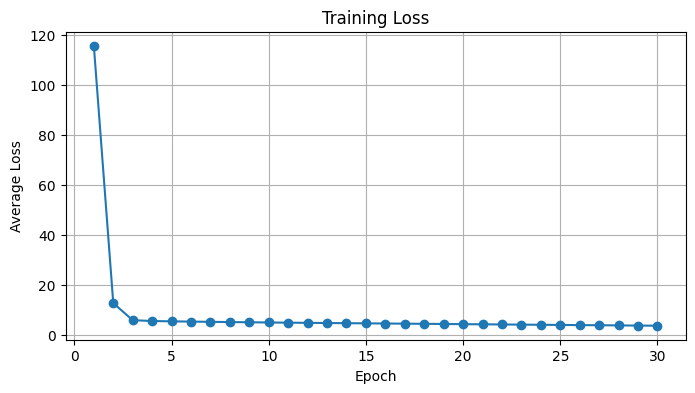

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

### 4. 추론 함수 (Greedy Decoding)

In [79]:
def generate(sentence, model=None, max_len=40, verbose=False):
    """문장 입력 → 챗봇 답변 생성 (Greedy)"""
    if model is None:
        model = transformer
    
    model.eval()
    
    # 전처리 + SentencePiece 토큰화
    cleaned = preprocess_sentence(sentence)
    src_tokens = tokenizer.encode_as_pieces(cleaned)
    src_ids = [word2idx.get(t, UNK_ID) for t in src_tokens]
    
    if verbose:
        print(f"입력 토큰: {src_tokens}")
        print(f"입력 ID:   {src_ids}")
    
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    with torch.no_grad():
        # 디코더 시작: <start>
        tgt = torch.tensor([[START_ID]], dtype=torch.long, device=device)
        
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
            pred, _, _, _ = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
            
            next_id = pred[:, -1, :].argmax(dim=-1).item()
            tgt = torch.cat([tgt, torch.tensor([[next_id]], device=device)], dim=1)
            
            if next_id == END_ID:
                break
    
    # 토큰 → 텍스트
    out_ids = tgt[0, 1:].cpu().tolist()   # <start> 제외
    out_tokens = [idx2word[i] for i in out_ids]
    
    # 자연어 텍스트 (사람 읽기용)
    natural = ''.join(out_tokens).replace('▁', ' ').replace('<end>', '').strip()
    
    # 토큰 형태 (제출용, 레퍼런스 양식과 동일)
    formatted = ' '.join(tok.replace('▁', '') for tok in out_tokens)
    
    return natural, formatted, out_tokens

### 5. 예문 테스트 (제출용)

In [80]:
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("="*70)
print("Translations")
print("="*70)
for i, s in enumerate(test_sentences, 1):
    natural, formatted, tokens = generate(s)
    print(f"{i}. {formatted}")

print("\n" + "="*70)
print("Hyperparameters")
print("="*70)
print(f"n_layers: 1")
print(f"d_model:  {d_model}")
print(f"n_heads:  8")
print(f"d_ff:     2048")
print(f"dropout:  0.3")

print("\nTraining Parameters")
print("="*70)
print(f"Warmup Steps: {learning_rate.warmup_steps}")
print(f"Batch Size:   {BATCH_SIZE}")
print(f"Epochs:       {EPOCHS}")

# 자연어 버전도 같이 보기 (디버깅용)
print("\n" + "="*70)
print("자연어 버전 (참고)")
print("="*70)
for i, s in enumerate(test_sentences, 1):
    natural, _, _ = generate(s)
    print(f"Q{i}: {s}")
    print(f"A{i}: {natural}\n")

Translations
1. 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이
2. 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이
3. 좋은 만남이었길 바라요 . <end>
4. 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이

Hyperparameters
n_layers: 1
d_model:  512
n_heads:  8
d_ff:     2048
dropout:  0.3

Training Parameters
Warmup Steps: 1000
Batch Size:   64
Epochs:       30

자연어 버전 (참고)
Q1: 지루하다, 놀러가고 싶어.
A1: 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이

Q2: 오늘 일찍 일어났더니 피곤하다.
A2: 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이

Q3: 간만에 여자친구랑 데이트 하기로 했어.
A3: 좋은 만남이었길 바라요.

Q4: 집에 있는다는 소리야.
A4: 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 많이 

### 6. 자유 대화 (테스트)
학습 잘 됐으면 자유롭게 대화해보세요:

In [81]:
def chat(sentence):
    """대화형 테스트용 헬퍼"""
    natural, formatted, tokens = generate(sentence, verbose=True)
    print(f"\n💬 답변: {natural}")
    print(f"   토큰: {formatted}")
    return natural

# 테스트 예시
chat("오늘 너무 힘들었어")
chat("주말에 뭐 할까?")
chat("배고파")
chat("사랑이 뭘까?")

입력 토큰: ['▁오늘', '▁너무', '▁힘들', '었어']
입력 ID:   [80, 10, 159, 468]

💬 답변: 조심하세요.
   토큰: 조심하세요 . <end>
입력 토큰: ['▁주말에', '▁뭐', '▁할까', '?']
입력 ID:   [2910, 140, 228, 5]

💬 답변: 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는
   토큰: 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는 어울리는
입력 토큰: ['▁배고파']
입력 ID:   [2987]

💬 답변: 드세요
   토큰: 드세요 <end>
입력 토큰: ['▁사랑이', '▁뭘까', '?']
입력 ID:   [134, 738, 5]

💬 답변: 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은
   토큰: 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 

'사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은 사랑은'

### 생성 함수에 반복 페널티 + 약간의 샘플링을 추가로 반복 차단

In [83]:
def generate(sentence, model=None, max_len=40, 
             repetition_penalty=1.5, top_k=5, verbose=False):
    """반복 페널티 + top-k 샘플링 적용 생성"""
    if model is None:
        model = transformer
    
    model.eval()
    
    cleaned = preprocess_sentence(sentence)
    src_tokens = tokenizer.encode_as_pieces(cleaned)
    src_ids = [word2idx.get(t, UNK_ID) for t in src_tokens]
    
    if verbose:
        print(f"입력 토큰: {src_tokens}")
    
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    with torch.no_grad():
        tgt = torch.tensor([[START_ID]], dtype=torch.long, device=device)
        generated_ids = set()
        
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
            pred, _, _, _ = model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
            
            logits = pred[:, -1, :].squeeze(0)  # (vocab_size,)
            
            # 1) 반복 페널티: 이미 생성한 토큰의 확률 낮추기
            for tok_id in tgt[0].tolist():
                if tok_id > 3:  # 특수토큰 제외
                    logits[tok_id] /= repetition_penalty
            
            # 2) Top-k 샘플링 (greedy보다 다양성 ↑)
            top_k_logits, top_k_indices = torch.topk(logits, top_k)
            probs = torch.softmax(top_k_logits, dim=-1)
            next_id = top_k_indices[torch.multinomial(probs, 1)].item()
            
            tgt = torch.cat([tgt, torch.tensor([[next_id]], device=device)], dim=1)
            
            if next_id == END_ID:
                break
    
    out_ids = tgt[0, 1:].cpu().tolist()
    out_tokens = [idx2word[i] for i in out_ids]
    
    natural = ''.join(out_tokens).replace('▁', ' ').replace('<end>', '').strip()
    formatted = ' '.join(tok.replace('▁', '') for tok in out_tokens)
    
    return natural, formatted, out_tokens

In [84]:
def chat(sentence):
    """대화형 테스트용 헬퍼"""
    natural, formatted, tokens = generate(sentence, verbose=True)
    print(f"\n💬 답변: {natural}")
    print(f"   토큰: {formatted}")
    return natural

# 테스트 예시
chat("오늘 너무 힘들었어")
chat("주말에 뭐 할까?")
chat("배고파")
chat("사랑이 뭘까?")

입력 토큰: ['▁오늘', '▁너무', '▁힘들', '었어']

💬 답변: 조심하세요.
   토큰: 조심하세요 . <end>
입력 토큰: ['▁주말에', '▁뭐', '▁할까', '?']

💬 답변: 같이 좋죠.
   토큰: 같이 좋죠 . <end>
입력 토큰: ['▁배고파']

💬 답변: 드세요
   토큰: 드세요 <end>
입력 토큰: ['▁사랑이', '▁뭘까', '?']

💬 답변: 사랑은 사람 만날 수 있으면입니다.
   토큰: 사랑은 사람 만날 수 있으면 입니다 . <end>


'사랑은 사람 만날 수 있으면입니다.'

In [85]:
chat("지루하다, 놀러가고 싶어.")
chat("오늘 일찍 일어났더니 피곤하다.")
chat("간만에 여자친구랑 데이트 하기로 했어.")
chat("집에 있는다는 소리야.")


입력 토큰: ['▁지루', '하다', ',', '▁놀러가고', '▁싶어', '.']

💬 답변: 세요
   토큰:  세요 <end>
입력 토큰: ['▁오늘', '▁일찍', '▁일어났', '더니', '▁피곤', '하다', '.']

💬 답변: 많이 많이 네요.
   토큰: 많이 많이  네요 . <end>
입력 토큰: ['▁간만에', '▁여자친구랑', '▁데이트', '▁하', '기로', '▁했어', '.']

💬 답변: 좋아하는 마음 가는 대로 하세요.
   토큰: 좋아하는 마음 가는 대로 하세요 . <end>
입력 토큰: ['▁집에', '▁있는', '다는', '▁소리', '야', '.']

💬 답변: 그럴 때가 있죠.
   토큰: 그럴 때가 있죠 . <end>


'그럴 때가 있죠.'

데이터 증강 + 중복제거 빼긴 했지만, 기존 30 에폭 모델은 그대로 쓰고 있으니까 아직 과적합 흔적이 남아있는 거예요.
즉시 시도: 파라미터 튜닝 (재학습 X)

In [86]:
# 더 강한 반복 페널티 + 적당한 다양성
chat_test = lambda s: generate(s, repetition_penalty=2.0, top_k=10)[0]

print(chat_test("지루하다, 놀러가고 싶어."))
print(chat_test("오늘 일찍 일어났더니 피곤하다."))
print(chat_test("간만에 여자친구랑 데이트 하기로 했어."))
print(chat_test("집에 있는다는 소리야."))

많이 들죠!
한 순간 해요. 다음에 기대세요!
잖아요.
전 전 안 좋은 방법 그럴 수 있어요.


# 더 나은 방법: Beam Search
Greedy/샘플링보다 안정적이고 자연스러워요:

In [87]:
def generate_beam(sentence, beam_width=5, max_len=40, length_penalty=0.6):
    """Beam Search 생성 (greedy보다 자연스럽고 일관됨)"""
    transformer.eval()
    
    cleaned = preprocess_sentence(sentence)
    src_tokens = tokenizer.encode_as_pieces(cleaned)
    src_ids = [word2idx.get(t, UNK_ID) for t in src_tokens]
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    
    with torch.no_grad():
        # beams: List of (sequence, score, finished)
        beams = [(torch.tensor([[START_ID]], device=device), 0.0, False)]
        
        for step in range(max_len):
            all_candidates = []
            
            for seq, score, finished in beams:
                if finished:
                    all_candidates.append((seq, score, True))
                    continue
                
                enc_mask, dec_enc_mask, dec_mask = generate_masks(src, seq)
                pred, _, _, _ = transformer(src, seq, enc_mask, dec_enc_mask, dec_mask)
                
                log_probs = torch.log_softmax(pred[:, -1, :], dim=-1).squeeze(0)
                top_log_probs, top_ids = torch.topk(log_probs, beam_width)
                
                for lp, tid in zip(top_log_probs.tolist(), top_ids.tolist()):
                    new_seq = torch.cat([seq, torch.tensor([[tid]], device=device)], dim=1)
                    new_score = score + lp
                    is_finished = (tid == END_ID)
                    all_candidates.append((new_seq, new_score, is_finished))
            
            # 길이 정규화 점수로 상위 beam_width개 선택
            all_candidates.sort(
                key=lambda x: x[1] / (x[0].size(1) ** length_penalty),
                reverse=True,
            )
            beams = all_candidates[:beam_width]
            
            # 모든 beam이 끝났으면 종료
            if all(b[2] for b in beams):
                break
        
        # 최고 점수 빔 선택
        best_seq, _, _ = max(beams, key=lambda x: x[1] / (x[0].size(1) ** length_penalty))
    
    out_ids = best_seq[0, 1:].cpu().tolist()
    out_tokens = [idx2word[i] for i in out_ids]
    natural = ''.join(out_tokens).replace('▁', ' ').replace('<end>', '').strip()
    formatted = ' '.join(tok.replace('▁', '') for tok in out_tokens)
    
    return natural, formatted, out_tokens




In [88]:
# 테스트
for s in [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]:
    natural, formatted, _ = generate_beam(s, beam_width=5)
    print(f"Q: {s}")
    print(f"A: {natural}")
    print(f"   ({formatted})\n")

Q: 지루하다, 놀러가고 싶어.
A: 세요.
   ( 세요 . <end>)

Q: 오늘 일찍 일어났더니 피곤하다.
A: 한 잔.
   (한 잔 . <end>)

Q: 간만에 여자친구랑 데이트 하기로 했어.
A: 좋은 만남이었길 바라요.
   (좋은 만남이었길 바라요 . <end>)

Q: 집에 있는다는 소리야.
A: 쉽지 않죠.
   (쉽지 않죠 . <end>)



## epoch 10, 15, 20회 돌면서 체크포인트 저장

In [92]:
import os
os.makedirs('./checkpoints', exist_ok=True)

# 모델 다시 초기화 (시드 고정)
torch.manual_seed(42)
d_model = 512  # 또는 256

transformer = Transformer(
    n_layers=1, d_model=d_model, n_heads=8, d_ff=2048,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE,
    pos_len=200, dropout=0.3,
    shared_fc=True, shared_emb=True,
).to(device)

learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)
optimizer = torch.optim.Adam(
    transformer.parameters(), lr=learning_rate(1),
    betas=(0.9, 0.98), eps=1e-9,
)

EPOCHS = 20
CHECKPOINT_EPOCHS = {10, 15, 20}  # 이 시점들에서 저장
SAMPLE_Q = "오늘 너무 힘들었어"

step_count = 0
epoch_losses = []

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for src, tgt in pbar:
        step_count += 1
        loss = train_step(src, tgt, transformer, optimizer, learning_rate, step_count)
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_loss = total_loss / len(train_dataloader)
    epoch_losses.append(avg_loss)
    
    # 매 에폭 후 샘플 생성 (greedy로 빠르게 확인)
    natural, _, _ = generate(SAMPLE_Q, top_k=1)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f} | '{SAMPLE_Q}' → '{natural}'")
    
    # 체크포인트 저장
    if (epoch + 1) in CHECKPOINT_EPOCHS:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': transformer.state_dict(),
            'loss': avg_loss,
        }, f'./checkpoints/chatbot_epoch_{epoch+1}.pt')
        print(f"  → checkpoint saved")

Epoch 1/20:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 1: loss=198.8810 | '오늘 너무 힘들었어' → '.'


Epoch 2/20:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 2: loss=22.9460 | '오늘 너무 힘들었어' → '.'


Epoch 3/20:   0%|          | 0/276 [00:00<?, ?it/s]

...

Epoch 18: loss=4.4815 | '오늘 너무 힘들었어' → '너무 너무 세요.'


Epoch 19/20:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 19: loss=4.4077 | '오늘 너무 힘들었어' → '세요.'


Epoch 20/20:   0%|          | 0/276 [00:00<?, ?it/s]

Epoch 20: loss=4.3381 | '오늘 너무 힘들었어' → '세요.'
  → checkpoint saved


In [93]:
def evaluate_checkpoint(ckpt_path):
    """체크포인트 로드해서 예문 4개 답변 생성"""
    ckpt = torch.load(ckpt_path)
    transformer.load_state_dict(ckpt['model_state_dict'])
    
    print(f"\n=== Epoch {ckpt['epoch']} (loss={ckpt['loss']:.4f}) ===")
    for i, s in enumerate([
        "지루하다, 놀러가고 싶어.",
        "오늘 일찍 일어났더니 피곤하다.",
        "간만에 여자친구랑 데이트 하기로 했어.",
        "집에 있는다는 소리야.",
    ], 1):
        natural, _, _ = generate(s, repetition_penalty=1.5, top_k=5)
        print(f"  {i}. {natural}")

# 모든 체크포인트 비교
for ep in [10, 15, 20]:
    evaluate_checkpoint(f'./checkpoints/chatbot_epoch_{ep}.pt')


=== Epoch 10 (loss=5.1130) ===
  1. 이제 세요.
  2. 마음이 세요.
  3. 좋은 사람 많이 세요.
  4. 더 좋은 건 네요.

=== Epoch 15 (loss=4.7102) ===
  1. 좋은 생각이에요!
  2. 많이 많이 좀 더 잘 수 있어요!
  3. 많이 좀 더 시간이 시간이 세요.
  4. 마음이 많이 세요.

=== Epoch 20 (loss=4.3381) ===
  1. 같이 많이 시간이 더 좀 좋은 날기기.
  2. 더 더 잘 안 돼요.
  3. 마음이 좀 더 좋은 세요.
  4. 잘 세요.


# 중복제거해서 모델 다시 훈련해보기

셀 1: 중복 제거된 데이터로 새 corpus 구축

In [94]:
# ===== build_corpus의 strict dedup으로 35k → 11k =====
que_corpus, ans_corpus = build_corpus(
    final_questions, final_answers,
    tokenizer.encode_as_pieces,
    max_len=40,
)
print(f"증강+중복제거 후: {len(que_corpus):,}쌍")  # ~11,000

# ===== 타겟에 <start>, <end> 추가 =====
ans_corpus = [['<start>'] + a + ['<end>'] for a in ans_corpus]

print(f"que_corpus[0]: {que_corpus[0]}")
print(f"ans_corpus[0]: {ans_corpus[0]}")

증강+중복제거 후: 11,024쌍
que_corpus[0]: ['▁12', '시', '▁땡', '!']
ans_corpus[0]: ['<start>', '▁하루가', '▁또', '▁가네요', '.', '<end>']


셀 2: 단어 사전 재구축 + 벡터화

In [95]:
from collections import Counter
import numpy as np

PAD_TOKEN, UNK_TOKEN = '<pad>', '<unk>'
START_TOKEN, END_TOKEN = '<start>', '<end>'
special_tokens = [PAD_TOKEN, UNK_TOKEN, START_TOKEN, END_TOKEN]

# 빈도 카운트
counter = Counter()
for tokens in que_corpus + ans_corpus:
    counter.update(tokens)
for tok in special_tokens:
    counter.pop(tok, None)

# 사전 구축
idx2word = special_tokens + [tok for tok, _ in counter.most_common()]
word2idx = {tok: i for i, tok in enumerate(idx2word)}

VOCAB_SIZE = len(idx2word)
PAD_ID, UNK_ID, START_ID, END_ID = 0, 1, 2, 3

print(f"Vocab size: {VOCAB_SIZE:,}")

# 벡터화 + 패딩
def encode(tokens):
    return [word2idx.get(tok, UNK_ID) for tok in tokens]

def pad_sequences(seqs, pad_id=PAD_ID, max_len=None):
    if max_len is None:
        max_len = max(len(s) for s in seqs)
    padded = np.full((len(seqs), max_len), pad_id, dtype=np.int64)
    for i, s in enumerate(seqs):
        length = min(len(s), max_len)
        padded[i, :length] = s[:length]
    return padded

enc_train = pad_sequences([encode(t) for t in que_corpus])
dec_train = pad_sequences([encode(t) for t in ans_corpus])

enc_train = torch.from_numpy(enc_train).long()
dec_train = torch.from_numpy(dec_train).long()

print(f"enc_train shape: {enc_train.shape}")
print(f"dec_train shape: {dec_train.shape}")

Vocab size: 7,751
enc_train shape: torch.Size([11024, 20])
dec_train shape: torch.Size([11024, 31])


셀 3: DataLoader

In [96]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_dataset = TensorDataset(enc_train, dec_train)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
print(f"배치 수: {len(train_dataloader)}")

배치 수: 173


셀 4: 모델 재초기화 (작은 데이터용)

In [97]:
# 11k 데이터엔 d_model=512가 과합니다 → 256으로 줄이고 dropout 강화
torch.manual_seed(42)
d_model = 256

transformer = Transformer(
    n_layers=2,        # 1 → 2 (살짝 깊게)
    d_model=d_model,   # 512 → 256
    n_heads=8,
    d_ff=1024,         # 2048 → 1024
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.35,      # 0.3 → 0.35 (작은 데이터 정규화 강화)
    shared_fc=True,
    shared_emb=True,
).to(device)

learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)
optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=learning_rate(1),
    betas=(0.9, 0.98),
    eps=1e-9,
)

print(f"모델 파라미터: {sum(p.numel() for p in transformer.parameters()):,}")

모델 파라미터: 5,679,431


셀 5: 학습 + 체크포인트 + 에폭별 샘플

In [98]:
import os
from tqdm.auto import tqdm

os.makedirs('./checkpoints', exist_ok=True)

EPOCHS = 15
CHECKPOINT_EPOCHS = {5, 8, 10, 12, 15}   # 이 시점들 저장
SAMPLE_Q = "오늘 너무 힘들었어"

# train_step (재정의 — 만약 이미 정의돼있다면 생략 가능)
def train_step(src, tgt, model, optimizer, lr_scheduler, step_count):
    model.train()
    optimizer.zero_grad()
    
    lr = lr_scheduler(step_count)
    for g in optimizer.param_groups:
        g['lr'] = lr
    
    src = src.to(device, non_blocking=True)
    tgt = tgt.to(device, non_blocking=True)
    
    tgt_in = tgt[:, :-1]
    gold = tgt[:, 1:]
    
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    
    pred, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, pred)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss

# 학습 루프
step_count = 0
epoch_losses = []

print(f"\n학습 시작: {len(train_dataset):,}쌍, 배치 {BATCH_SIZE}, 에폭 {EPOCHS}")
print(f"디바이스: {device}\n")

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for src, tgt in pbar:
        step_count += 1
        loss = train_step(src, tgt, transformer, optimizer, learning_rate, step_count)
        total_loss += loss.item()
        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{optimizer.param_groups[0]['lr']:.6f}",
        )
    
    avg_loss = total_loss / len(train_dataloader)
    epoch_losses.append(avg_loss)
    
    # 에폭별 샘플 생성
    natural, _, _ = generate(SAMPLE_Q, top_k=1)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f} | '{SAMPLE_Q}' → '{natural}'")
    
    # 체크포인트 저장
    if (epoch + 1) in CHECKPOINT_EPOCHS:
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': transformer.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
            'word2idx': word2idx,
            'idx2word': idx2word,
            'config': {
                'd_model': d_model, 'n_layers': 2, 'n_heads': 8,
                'd_ff': 1024, 'dropout': 0.35, 'vocab_size': VOCAB_SIZE,
            },
        }, f'./checkpoints/chatbot_11k_ep{epoch+1}.pt')
        print(f"  → 저장됨: chatbot_11k_ep{epoch+1}.pt")

print("\n학습 완료!")


학습 시작: 11,024쌍, 배치 64, 에폭 15
디바이스: cuda



Epoch 1/15:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 1: loss=137.8426 | '오늘 너무 힘들었어' → '.'


Epoch 2/15:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 2: loss=22.8044 | '오늘 너무 힘들었어' → '.'


...

Epoch 13: loss=5.3461 | '오늘 너무 힘들었어' → '좋은 세요.'


Epoch 14/15:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 14: loss=5.2997 | '오늘 너무 힘들었어' → '좋은 더 더 세요.'


Epoch 15/15:   0%|          | 0/173 [00:00<?, ?it/s]

Epoch 15: loss=5.2529 | '오늘 너무 힘들었어' → '더 더 세요.'
  → 저장됨: chatbot_11k_ep15.pt

학습 완료!


 셀 6: 각 체크포인트로 예문 4개 비교

In [99]:
def evaluate_checkpoint(ckpt_path):
    ckpt = torch.load(ckpt_path, weights_only=False)
    transformer.load_state_dict(ckpt['model_state_dict'])
    
    print(f"\n=== Epoch {ckpt['epoch']} (loss={ckpt['loss']:.4f}) ===")
    test_sentences = [
        "지루하다, 놀러가고 싶어.",
        "오늘 일찍 일어났더니 피곤하다.",
        "간만에 여자친구랑 데이트 하기로 했어.",
        "집에 있는다는 소리야.",
    ]
    for i, s in enumerate(test_sentences, 1):
        natural, _, _ = generate(s, repetition_penalty=1.5, top_k=5)
        print(f"  {i}. Q: {s}")
        print(f"     A: {natural}")

for ep in sorted(CHECKPOINT_EPOCHS):
    evaluate_checkpoint(f'./checkpoints/chatbot_11k_ep{ep}.pt')


=== Epoch 5 (loss=7.6568) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 수.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: .
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 거예요.
  4. Q: 집에 있는다는 소리야.
     A: 더.

=== Epoch 8 (loss=5.7170) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 좋은 을을 잘 잘도.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 그럴 수 있을 거예요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 잘 잘세요.
  4. Q: 집에 있는다는 소리야.
     A: 잘 좋은 더도을 거예요.

=== Epoch 10 (loss=5.5359) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 잘 잘 더 을세요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 좋은 좋은 더 더 수 있어요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 잘 좋은  더 더 수 있을 거예요.
  4. Q: 집에 있는다는 소리야.
     A: 많이 더 사람 잘 수 있는 거예요.

=== Epoch 12 (loss=5.4026) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 다른 더 더   해보세요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 다른 혈육.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 많이 세요.
  4. Q: 집에 있는다는 소리야.
     A: 그 더 더 세요.

=== Epoch 15 (loss=5.2529) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 세요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 이제 사람 잘 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 좋은 더 세요.
  4. Q: 집에 있는다는 소리야.

## 이상한 증강도 11k 데이터사이즈에서는 있는게 훨씬 좋았음.

In [104]:
# 35k 증강 데이터가 메모리에 있는지
print(f"final_questions 길이: {len(final_questions):,}")
print(f"샘플: {final_questions[0]}")

final_questions 길이: 35,324
샘플: 12시 땡!


## 메모리에 중복 제거 이전 데이터 남아있음.

In [103]:
from collections import Counter

# 옛날과 동일한 토큰화 (중복 제거 X)
def tokenize_corpus_no_dedup(src_sentences, tgt_sentences, tokenize_fn, max_len=40):
    src_corpus, tgt_corpus = [], []
    for src, tgt in zip(src_sentences, tgt_sentences):
        s = tokenize_fn(preprocess_sentence(src))
        t = tokenize_fn(preprocess_sentence(tgt))
        if len(s) > max_len or len(t) > max_len:
            continue
        src_corpus.append(s)
        tgt_corpus.append(t)
    return src_corpus, tgt_corpus

que_old, ans_old = tokenize_corpus_no_dedup(
    final_questions, final_answers,
    tokenizer.encode_as_pieces, max_len=40,
)
ans_old = [['<start>'] + a + ['<end>'] for a in ans_old]

# 옛날과 동일한 vocab 구축
special_tokens = ['<pad>', '<unk>', '<start>', '<end>']
counter = Counter()
for tokens in que_old + ans_old:
    counter.update(tokens)
for tok in special_tokens:
    counter.pop(tok, None)

idx2word = special_tokens + [tok for tok, _ in counter.most_common()]
word2idx = {tok: i for i, tok in enumerate(idx2word)}
VOCAB_SIZE = len(idx2word)

print(f"재구성된 vocab: {VOCAB_SIZE}")

재구성된 vocab: 7895


### 이건 못씀 새로만들어야함.

### 35k모델 (중복제거 전) 모델 새로만들고 파일로 저장

In [105]:
import torch
import os
import json
from collections import Counter

# ========== 1) 35k 데이터로 vocab 재구성 ==========
def tokenize_corpus_no_dedup(src_sentences, tgt_sentences, tokenize_fn, max_len=40):
    src_corpus, tgt_corpus = [], []
    for src, tgt in zip(src_sentences, tgt_sentences):
        s = tokenize_fn(preprocess_sentence(src))
        t = tokenize_fn(preprocess_sentence(tgt))
        if len(s) > max_len or len(t) > max_len:
            continue
        src_corpus.append(s)
        tgt_corpus.append(t)
    return src_corpus, tgt_corpus

que_old, ans_old = tokenize_corpus_no_dedup(
    final_questions, final_answers,
    tokenizer.encode_as_pieces, max_len=40,
)
ans_old = [['<start>'] + a + ['<end>'] for a in ans_old]

special_tokens = ['<pad>', '<unk>', '<start>', '<end>']
counter = Counter()
for tokens in que_old + ans_old:
    counter.update(tokens)
for tok in special_tokens:
    counter.pop(tok, None)

idx2word = special_tokens + [tok for tok, _ in counter.most_common()]
word2idx = {tok: i for i, tok in enumerate(idx2word)}
VOCAB_SIZE = len(idx2word)

print(f"Vocab size: {VOCAB_SIZE}")
assert VOCAB_SIZE == 7895, f"❌ Vocab 불일치: {VOCAB_SIZE}. 데이터가 바뀐 듯해요."
print("✅ Vocab 일치!")

PAD_ID, UNK_ID, START_ID, END_ID = 0, 1, 2, 3


# ========== 2) 모델 재생성 + 가중치 로드 ==========
torch.manual_seed(42)
d_model = 512

transformer = Transformer(
    n_layers=1,
    d_model=d_model,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=VOCAB_SIZE,
    tgt_vocab_size=VOCAB_SIZE,
    pos_len=200,
    dropout=0.3,
    shared_fc=True,
    shared_emb=True,
).to(device)

ckpt = torch.load('./checkpoints/chatbot_epoch_15.pt', weights_only=False)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    transformer.load_state_dict(ckpt['model_state_dict'])
    original_loss = ckpt.get('loss', None)
else:
    transformer.load_state_dict(ckpt)
    original_loss = None

print("✅ 가중치 로드 완료!")


# ========== 3) 모든 것을 한 파일로 저장 ==========
os.makedirs('./checkpoints', exist_ok=True)
save_path = './checkpoints/chatbot_35k_epoch15_full.pt'

torch.save({
    'epoch': 15,
    'model_state_dict': transformer.state_dict(),
    'word2idx': word2idx,
    'idx2word': idx2word,
    'vocab_size': VOCAB_SIZE,
    'config': {
        'n_layers': 1,
        'd_model': 512,
        'n_heads': 8,
        'd_ff': 2048,
        'dropout': 0.3,
        'pos_len': 200,
        'shared_fc': True,
        'shared_emb': True,
    },
    'special_tokens': {
        'PAD_ID': 0, 'UNK_ID': 1, 'START_ID': 2, 'END_ID': 3,
    },
    'loss': original_loss,
    'description': '35k augmented data, epoch 15, d_model=512, n_layers=1',
}, save_path)

size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"✅ 통합 체크포인트 저장: {save_path} ({size_mb:.1f} MB)")


# ========== 4) vocab만 별도 JSON 백업 (안전) ==========
vocab_path = './checkpoints/vocab_35k.json'
with open(vocab_path, 'w', encoding='utf-8') as f:
    json.dump({
        'word2idx': word2idx,
        'idx2word': idx2word,
        'vocab_size': VOCAB_SIZE,
        'special_tokens': {
            'PAD_ID': 0, 'UNK_ID': 1, 'START_ID': 2, 'END_ID': 3,
        },
    }, f, ensure_ascii=False, indent=2)

print(f"✅ Vocab JSON 백업: {vocab_path}")

Vocab size: 7895
✅ Vocab 일치!
✅ 가중치 로드 완료!
✅ 통합 체크포인트 저장: ./checkpoints/chatbot_35k_epoch15_full.pt (44.1 MB)
✅ Vocab JSON 백업: ./checkpoints/vocab_35k.json


### 나중에 한 줄로 로드하는 헬퍼 함수

In [ ]:
# def load_full_checkpoint(path, device='cuda'):
#     """vocab + config + 가중치 모두 포함된 체크포인트 로드"""
#     ckpt = torch.load(path, weights_only=False, map_location=device)
#     cfg = ckpt['config']
    
#     model = Transformer(
#         n_layers=cfg['n_layers'],
#         d_model=cfg['d_model'],
#         n_heads=cfg['n_heads'],
#         d_ff=cfg['d_ff'],
#         src_vocab_size=ckpt['vocab_size'],
#         tgt_vocab_size=ckpt['vocab_size'],
#         pos_len=cfg['pos_len'],
#         dropout=cfg['dropout'],
#         shared_fc=cfg['shared_fc'],
#         shared_emb=cfg['shared_emb'],
#     ).to(device)
#     model.load_state_dict(ckpt['model_state_dict'])
    
#     return {
#         'model': model,
#         'word2idx': ckpt['word2idx'],
#         'idx2word': ckpt['idx2word'],
#         'vocab_size': ckpt['vocab_size'],
#         'config': cfg,
#         'special_tokens': ckpt['special_tokens'],
#         'epoch': ckpt.get('epoch'),
#         'loss': ckpt.get('loss'),
#     }


# # 다음에 이렇게 한 줄로:
# state = load_full_checkpoint('./checkpoints/chatbot_35k_epoch15_full.pt', device=device)
# transformer = state['model']
# word2idx = state['word2idx']
# idx2word = state['idx2word']
# VOCAB_SIZE = state['vocab_size']
# PAD_ID = state['special_tokens']['PAD_ID']
# UNK_ID = state['special_tokens']['UNK_ID']
# START_ID = state['special_tokens']['START_ID']
# END_ID = state['special_tokens']['END_ID']

# print(f"Epoch {state['epoch']} 모델 복원 완료 (vocab={VOCAB_SIZE})")

### 저장 검증

In [106]:
# 잘 저장됐는지 확인
verify = torch.load(save_path, weights_only=False)
print(f"저장된 키: {list(verify.keys())}")
print(f"vocab_size: {verify['vocab_size']}")
print(f"config: {verify['config']}")
print(f"word2idx 일부: {list(verify['word2idx'].items())[:5]}")
print(f"idx2word 일부: {verify['idx2word'][:10]}")

저장된 키: ['epoch', 'model_state_dict', 'word2idx', 'idx2word', 'vocab_size', 'config', 'special_tokens', 'loss', 'description']
vocab_size: 7895
config: {'n_layers': 1, 'd_model': 512, 'n_heads': 8, 'd_ff': 2048, 'dropout': 0.3, 'pos_len': 200, 'shared_fc': True, 'shared_emb': True}
word2idx 일부: [('<pad>', 0), ('<unk>', 1), ('<start>', 2), ('<end>', 3), ('.', 4)]
idx2word 일부: ['<pad>', '<unk>', '<start>', '<end>', '.', '?', '▁', '▁거예요', '▁수', '이']


### 챗봇 동작 확인

In [107]:
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

print("="*60)
print("Translations (35k Epoch 15)")
print("="*60)
for i, s in enumerate(test_sentences, 1):
    _, formatted, _ = generate(s, repetition_penalty=1.5, top_k=5)
    print(f"{i}. {formatted}")

Translations (35k Epoch 15)
1. 많이  세요 . <end>
2. 잘 잘  세요 . <end>
3. 마음이 좀 더  세요 . <end>
4. 좋은 시간 시간  세요 . <end>


In [108]:
len(final_questions)

35324

In [109]:
def evaluate_checkpoint(ckpt_path):
    """체크포인트 로드해서 예문 4개 답변 생성"""
    ckpt = torch.load(ckpt_path)
    transformer.load_state_dict(ckpt['model_state_dict'])
    
    print(f"\n=== Epoch {ckpt['epoch']} (loss={ckpt['loss']:.4f}) ===")
    for i, s in enumerate([
        "지루하다, 놀러가고 싶어.",
        "오늘 일찍 일어났더니 피곤하다.",
        "간만에 여자친구랑 데이트 하기로 했어.",
        "집에 있는다는 소리야.",
    ], 1):
        natural, _, _ = generate(s, repetition_penalty=1.5, top_k=5)
        print(f"  {i}. {natural}")

# 모든 체크포인트 비교
for ep in [10, 15, 20]:
    evaluate_checkpoint(f'./checkpoints/chatbot_epoch_{ep}.pt')


=== Epoch 10 (loss=5.1130) ===
  1. 좋은 생각이에요.
  2. 잘 네요.
  3. 잘 많이 많이 시간이 혈육.
  4. 마음이 마음이 좋은 사람 많이 더 잘 세요.

=== Epoch 15 (loss=4.7102) ===
  1. 많이 세요.
  2. 잘 많이 더 세요.
  3. 이제 세요.
  4. 많이 마음을 사람이 수 있을 거예요.

=== Epoch 20 (loss=4.3381) ===
  1. 조금씩 시간이 많이.
  2. 어요.
  3. 세요.
  4. 잘 많이 마음을 정리길 바랍니다.


### 아무래도 35k모델 복원이 잘 안된거같음 데이터 증강 다시 재현

## 셀 1: 데이터 증강 (재현 가능하게)

In [111]:
import random
import re
import torch
import numpy as np
from collections import Counter

# 시드 고정으로 재현성 보장
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)

# ===== 1) 전처리된 문자열 (이미 있으면 스킵) =====
questions = list(map(preprocess_sentence, df['Q'].tolist()))
answers   = list(map(preprocess_sentence, df['A'].tolist()))

# ===== 2) 3배 증강 =====
original_pairs = list(zip(questions, answers))
aug_q_pairs = [(lexical_sub(q, ft), a) for q, a in zip(questions, answers)]
aug_a_pairs = [(q, lexical_sub(a, ft)) for q, a in zip(questions, answers)]

all_pairs = original_pairs + aug_q_pairs + aug_a_pairs

# ===== 3) (Q,A) 쌍 중복 제거 =====
seen = set()
unique_pairs = []
for q, a in all_pairs:
    if (q, a) not in seen:
        seen.add((q, a))
        unique_pairs.append((q, a))

final_questions = [q for q, _ in unique_pairs]
final_answers   = [a for _, a in unique_pairs]

print(f"원본:        {len(questions):,}쌍")
print(f"증강 후:      {len(all_pairs):,}쌍")
print(f"쌍 중복제거:  {len(unique_pairs):,}쌍")

원본:        11,823쌍
증강 후:      35,469쌍
쌍 중복제거:  35,324쌍


### 셀 2: 토큰화 + vocab + 벡터화

In [112]:
# ===== 토큰화 (중복제거 X, 길이 필터만) =====
def tokenize_corpus(src_sentences, tgt_sentences, tokenize_fn, max_len=40):
    src_corpus, tgt_corpus = [], []
    for src, tgt in zip(src_sentences, tgt_sentences):
        s = tokenize_fn(preprocess_sentence(src))
        t = tokenize_fn(preprocess_sentence(tgt))
        if len(s) > max_len or len(t) > max_len:
            continue
        src_corpus.append(s)
        tgt_corpus.append(t)
    return src_corpus, tgt_corpus

que_corpus, ans_corpus = tokenize_corpus(
    final_questions, final_answers,
    tokenizer.encode_as_pieces, max_len=40,
)
ans_corpus = [['<start>'] + a + ['<end>'] for a in ans_corpus]

print(f"토큰화 후: {len(que_corpus):,}쌍")

# ===== Vocab 구축 =====
special_tokens = ['<pad>', '<unk>', '<start>', '<end>']
counter = Counter()
for tokens in que_corpus + ans_corpus:
    counter.update(tokens)
for tok in special_tokens:
    counter.pop(tok, None)

idx2word = special_tokens + [tok for tok, _ in counter.most_common()]
word2idx = {tok: i for i, tok in enumerate(idx2word)}

VOCAB_SIZE = len(idx2word)
PAD_ID, UNK_ID, START_ID, END_ID = 0, 1, 2, 3

print(f"Vocab size: {VOCAB_SIZE}")

# ===== 벡터화 + 패딩 =====
def encode(tokens):
    return [word2idx.get(tok, UNK_ID) for tok in tokens]

def pad_sequences(seqs, pad_id=PAD_ID, max_len=None):
    if max_len is None:
        max_len = max(len(s) for s in seqs)
    padded = np.full((len(seqs), max_len), pad_id, dtype=np.int64)
    for i, s in enumerate(seqs):
        length = min(len(s), max_len)
        padded[i, :length] = s[:length]
    return padded

enc_train = torch.from_numpy(pad_sequences([encode(t) for t in que_corpus])).long()
dec_train = torch.from_numpy(pad_sequences([encode(t) for t in ans_corpus])).long()

print(f"enc_train: {enc_train.shape}")
print(f"dec_train: {dec_train.shape}")

토큰화 후: 35,324쌍
Vocab size: 7895
enc_train: torch.Size([35324, 21])
dec_train: torch.Size([35324, 31])


### 셀 3: DataLoader + 모델 + 옵티마이저

In [113]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 64

train_dataset = TensorDataset(enc_train, dec_train)
train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=True,
)
print(f"배치 수: {len(train_dataloader)}")

# 모델
torch.manual_seed(42)
d_model = 512

transformer = Transformer(
    n_layers=1, d_model=d_model, n_heads=8, d_ff=2048,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE,
    pos_len=200, dropout=0.3,
    shared_fc=True, shared_emb=True,
).to(device)

learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)
optimizer = torch.optim.Adam(
    transformer.parameters(), lr=learning_rate(1),
    betas=(0.9, 0.98), eps=1e-9,
)

print(f"모델 파라미터: {sum(p.numel() for p in transformer.parameters()):,}")

배치 수: 552
모델 파라미터: 11,408,599


### 셀 4: 학습 (12, 15, 18 체크포인트 저장)

In [114]:
import os
from tqdm.auto import tqdm

os.makedirs('./checkpoints', exist_ok=True)

EPOCHS = 20
CHECKPOINT_EPOCHS = {12, 15, 18}  # 이 시점들에서 저장
SAMPLE_Q = "오늘 너무 힘들었어"

def train_step(src, tgt, model, optimizer, lr_scheduler, step_count):
    model.train()
    optimizer.zero_grad()
    
    lr = lr_scheduler(step_count)
    for g in optimizer.param_groups:
        g['lr'] = lr
    
    src = src.to(device, non_blocking=True)
    tgt = tgt.to(device, non_blocking=True)
    
    tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    
    pred, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, pred)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss


step_count = 0
epoch_losses = []

print(f"학습 시작: {len(train_dataset):,}쌍, batch {BATCH_SIZE}, epochs {EPOCHS}\n")

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for src, tgt in pbar:
        step_count += 1
        loss = train_step(src, tgt, transformer, optimizer, learning_rate, step_count)
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.6f}")
    
    avg_loss = total_loss / len(train_dataloader)
    epoch_losses.append(avg_loss)
    
    # 에폭별 샘플 (Greedy로 빠르게)
    natural, _, _ = generate(SAMPLE_Q, top_k=1)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f} | '{SAMPLE_Q}' → '{natural}'")
    
    # 체크포인트 저장 (vocab + config 포함!)
    if (epoch + 1) in CHECKPOINT_EPOCHS:
        save_path = f'./checkpoints/chatbot_35k_ep{epoch+1}.pt'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': transformer.state_dict(),
            'word2idx': word2idx,
            'idx2word': idx2word,
            'vocab_size': VOCAB_SIZE,
            'config': {
                'n_layers': 1, 'd_model': d_model, 'n_heads': 8,
                'd_ff': 2048, 'dropout': 0.3, 'pos_len': 200,
                'shared_fc': True, 'shared_emb': True,
            },
            'special_tokens': {
                'PAD_ID': 0, 'UNK_ID': 1, 'START_ID': 2, 'END_ID': 3,
            },
            'loss': avg_loss,
        }, save_path)
        print(f"  → 저장: {save_path}")

print("\n✅ 학습 완료!")

학습 시작: 35,324쌍, batch 64, epochs 20



Epoch 1/20:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 1: loss=114.3166 | '오늘 너무 힘들었어' → '.'


Epoch 2/20:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 2: loss=12.8516 | '오늘 너무 힘들었어' → '잘 잘.'


...

Epoch 18: loss=4.4052 | '오늘 너무 힘들었어' → '많이 세요.'
  → 저장: ./checkpoints/chatbot_35k_ep18.pt


Epoch 19/20:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 19: loss=4.3371 | '오늘 너무 힘들었어' → '많이 세요.'


Epoch 20/20:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 20: loss=4.2666 | '오늘 너무 힘들었어' → '많이 세요.'

✅ 학습 완료!


### 체크포인트 별 비교

In [115]:
def load_and_evaluate(ckpt_path):
    """체크포인트 로드하고 예문 4개에 대해 답변 생성"""
    ckpt = torch.load(ckpt_path, weights_only=False)
    cfg = ckpt['config']
    
    # 모델 재생성
    model = Transformer(
        n_layers=cfg['n_layers'], d_model=cfg['d_model'], n_heads=cfg['n_heads'],
        d_ff=cfg['d_ff'], src_vocab_size=ckpt['vocab_size'], tgt_vocab_size=ckpt['vocab_size'],
        pos_len=cfg['pos_len'], dropout=cfg['dropout'],
        shared_fc=cfg['shared_fc'], shared_emb=cfg['shared_emb'],
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    
    # 전역 vocab 임시 교체 (generate가 전역 참조하니까)
    global word2idx, idx2word, transformer
    bk_w, bk_i, bk_t = word2idx, idx2word, transformer
    word2idx, idx2word, transformer = ckpt['word2idx'], ckpt['idx2word'], model
    
    print(f"\n=== Epoch {ckpt['epoch']} (loss={ckpt['loss']:.4f}) ===")
    for i, s in enumerate([
        "지루하다, 놀러가고 싶어.",
        "오늘 일찍 일어났더니 피곤하다.",
        "간만에 여자친구랑 데이트 하기로 했어.",
        "집에 있는다는 소리야.",
    ], 1):
        natural, _, _ = generate(s, repetition_penalty=1.5, top_k=5)
        print(f"  {i}. Q: {s}")
        print(f"     A: {natural}")
    
    # 복원
    word2idx, idx2word, transformer = bk_w, bk_i, bk_t


# 3개 체크포인트 모두 평가
for ep in [12, 15, 18]:
    load_and_evaluate(f'./checkpoints/chatbot_35k_ep{ep}.pt')


=== Epoch 12 (loss=4.8310) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 좋은 좋을 거 같아요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 저도 많이 많이 혈육.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 좋은 더 혈육.
  4. Q: 집에 있는다는 소리야.
     A: 많이 세요.

=== Epoch 15 (loss=4.6129) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 같이 더 세요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 마음이 더 잘 있어요.
  4. Q: 집에 있는다는 소리야.
     A: 잘 될 거예요.

=== Epoch 18 (loss=4.4052) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 같이 세요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 많이 많이 던 힘든 건 아닌지 거예요.
  4. Q: 집에 있는다는 소리야.
     A: 잘 될 거예요.


아래 사진 6epoch 보고 10+ epoch는 이미 과적합아닌가 해서 checkpoint마다 저장하도록 해서 다시학습
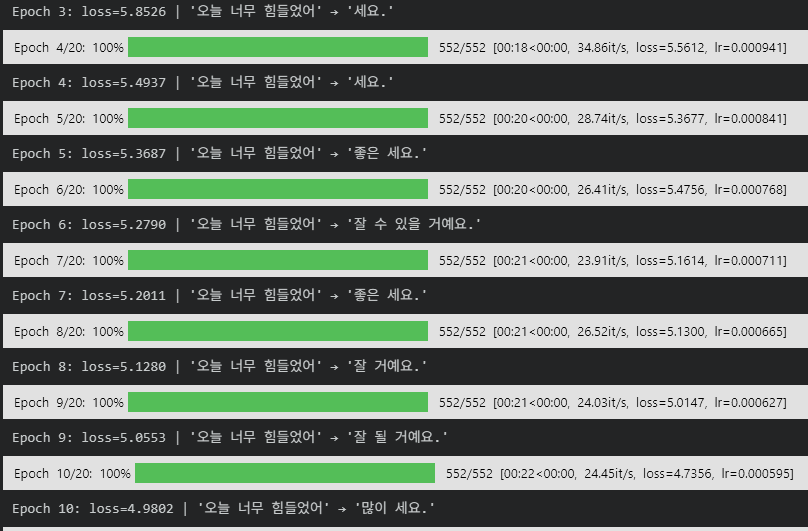

### 총 15 epoch

In [116]:
import os
from tqdm.auto import tqdm

os.makedirs('./checkpoints', exist_ok=True)

EPOCHS = 15
CHECKPOINT_EPOCHS = {1,2,3,4,5,6,7,8,9,10,11,12,13,14,15}  # 이 시점들에서 저장
SAMPLE_Q = "오늘 너무 힘들었어"

def train_step(src, tgt, model, optimizer, lr_scheduler, step_count):
    model.train()
    optimizer.zero_grad()
    
    lr = lr_scheduler(step_count)
    for g in optimizer.param_groups:
        g['lr'] = lr
    
    src = src.to(device, non_blocking=True)
    tgt = tgt.to(device, non_blocking=True)
    
    tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    
    pred, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, pred)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss


step_count = 0
epoch_losses = []

print(f"학습 시작: {len(train_dataset):,}쌍, batch {BATCH_SIZE}, epochs {EPOCHS}\n")

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for src, tgt in pbar:
        step_count += 1
        loss = train_step(src, tgt, transformer, optimizer, learning_rate, step_count)
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.6f}")
    
    avg_loss = total_loss / len(train_dataloader)
    epoch_losses.append(avg_loss)
    
    # 에폭별 샘플 (Greedy로 빠르게)
    natural, _, _ = generate(SAMPLE_Q, top_k=1)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f} | '{SAMPLE_Q}' → '{natural}'")
    
    # 체크포인트 저장 (vocab + config 포함!)
    if (epoch + 1) in CHECKPOINT_EPOCHS:
        save_path = f'./checkpoints/chatbot_35k_ep{epoch+1}.pt'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': transformer.state_dict(),
            'word2idx': word2idx,
            'idx2word': idx2word,
            'vocab_size': VOCAB_SIZE,
            'config': {
                'n_layers': 1, 'd_model': d_model, 'n_heads': 8,
                'd_ff': 2048, 'dropout': 0.3, 'pos_len': 200,
                'shared_fc': True, 'shared_emb': True,
            },
            'special_tokens': {
                'PAD_ID': 0, 'UNK_ID': 1, 'START_ID': 2, 'END_ID': 3,
            },
            'loss': avg_loss,
        }, save_path)
        print(f"  → 저장: {save_path}")

print("\n✅ 학습 완료!")

학습 시작: 35,324쌍, batch 64, epochs 15



Epoch 1/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 1: loss=4.2084 | '오늘 너무 힘들었어' → '많이 지쳤나봐요.'
  → 저장: ./checkpoints/chatbot_35k_ep1.pt


Epoch 2/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 2: loss=4.1985 | '오늘 너무 힘들었어' → '많이 지쳤나봐요.'
  → 저장: ./checkpoints/chatbot_35k_ep2.pt


...

Epoch 13: loss=3.0259 | '오늘 너무 힘들었어' → '감기 조심하세요.'
  → 저장: ./checkpoints/chatbot_35k_ep13.pt


Epoch 14/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 14: loss=2.9415 | '오늘 너무 힘들었어' → '감기 조심하세요.'
  → 저장: ./checkpoints/chatbot_35k_ep14.pt


Epoch 15/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 15: loss=2.8768 | '오늘 너무 힘들었어' → '감기 조심하세요.'
  → 저장: ./checkpoints/chatbot_35k_ep15.pt

✅ 학습 완료!


In [117]:
def load_and_evaluate(ckpt_path):
    """체크포인트 로드하고 예문 4개에 대해 답변 생성"""
    ckpt = torch.load(ckpt_path, weights_only=False)
    cfg = ckpt['config']
    
    # 모델 재생성
    model = Transformer(
        n_layers=cfg['n_layers'], d_model=cfg['d_model'], n_heads=cfg['n_heads'],
        d_ff=cfg['d_ff'], src_vocab_size=ckpt['vocab_size'], tgt_vocab_size=ckpt['vocab_size'],
        pos_len=cfg['pos_len'], dropout=cfg['dropout'],
        shared_fc=cfg['shared_fc'], shared_emb=cfg['shared_emb'],
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    
    # 전역 vocab 임시 교체 (generate가 전역 참조하니까)
    global word2idx, idx2word, transformer
    bk_w, bk_i, bk_t = word2idx, idx2word, transformer
    word2idx, idx2word, transformer = ckpt['word2idx'], ckpt['idx2word'], model
    
    print(f"\n=== Epoch {ckpt['epoch']} (loss={ckpt['loss']:.4f}) ===")
    for i, s in enumerate([
        "지루하다, 놀러가고 싶어.",
        "오늘 일찍 일어났더니 피곤하다.",
        "간만에 여자친구랑 데이트 하기로 했어.",
        "집에 있는다는 소리야.",
    ], 1):
        natural, _, _ = generate(s, repetition_penalty=1.5, top_k=5)
        print(f"  {i}. Q: {s}")
        print(f"     A: {natural}")
    
    # 복원
    word2idx, idx2word, transformer = bk_w, bk_i, bk_t


# 3개 체크포인트 모두 평가
for ep in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    load_and_evaluate(f'./checkpoints/chatbot_35k_ep{ep}.pt')


=== Epoch 1 (loss=4.2084) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 좋은 싶어요!
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 좋은 사람 만나세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 마음이 복잡네요.
  4. Q: 집에 있는다는 소리야.
     A: 제가 네요.

=== Epoch 2 (loss=4.1985) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 같이 가는 대로 좋죠.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 잘 안 좋은 있어요.
  4. Q: 집에 있는다는 소리야.
     A: 제가 들어드릴게요.

=== Epoch 3 (loss=4.0889) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 좋아요!
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 마음이 복잡할 거예요.
  4. Q: 집에 있는다는 소리야.
     A: 잘 안되나봐요.

=== Epoch 4 (loss=3.9293) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 세요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 비셨나봐요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 좀 더 좋은 습니다.
  4. Q: 집에 있는다는 소리야.
     A: 이제 좀 괜찮아졌길 바랄게요.

=== Epoch 5 (loss=3.7888) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 당장 해보세요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 한 잔.
  4. Q: 집에 있는다는 소리야.
     A: 제가 힘들어하지 말고 많이 지쳤나봐

### 실수로 초기화 안하고 학습시작했는데 혹시나해서 지켜봤지만 결과 다안좋음. 과적합일까? 아니면 AI는 운빨인가 ㅠㅠ

### 초기화 하고 다시 학습 시키고 1epoch부터 15epoch까지 저장

In [118]:
import torch

# ===== 모델/옵티마이저/스텝 카운터 모두 리셋 =====
torch.manual_seed(42)
d_model = 512

# 1) 모델 새로 생성 (이게 핵심!)
transformer = Transformer(
    n_layers=1, d_model=d_model, n_heads=8, d_ff=2048,
    src_vocab_size=VOCAB_SIZE, tgt_vocab_size=VOCAB_SIZE,
    pos_len=200, dropout=0.3,
    shared_fc=True, shared_emb=True,
).to(device)

# 2) 옵티마이저 새로 생성 (momentum 등 상태 리셋)
learning_rate = LearningRateScheduler(d_model, warmup_steps=1000)
optimizer = torch.optim.Adam(
    transformer.parameters(), lr=learning_rate(1),
    betas=(0.9, 0.98), eps=1e-9,
)

# 3) 스텝 카운터 리셋 (warmup이 처음부터 동작)
step_count = 0
epoch_losses = []

# 4) 검증 — 새로 만든 모델인지 확인
print(f"모델 파라미터: {sum(p.numel() for p in transformer.parameters()):,}")

# 첫 번째 배치로 loss 확인 (115 근처면 정상 초기화)
sample_src, sample_tgt = next(iter(train_dataloader))
sample_src = sample_src.to(device)
sample_tgt = sample_tgt.to(device)
tgt_in = sample_tgt[:, :-1]
gold = sample_tgt[:, 1:]
enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, tgt_in)
with torch.no_grad():
    pred, _, _, _ = transformer(sample_src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    initial_loss = loss_function(gold, pred)
print(f"초기 loss: {initial_loss.item():.4f} (랜덤 초기화면 100 근처가 정상)")

모델 파라미터: 11,408,599
초기 loss: 425.5075 (랜덤 초기화면 100 근처가 정상)


In [119]:
import os
from tqdm.auto import tqdm

os.makedirs('./checkpoints', exist_ok=True)

EPOCHS = 15
CHECKPOINT_EPOCHS = {1,2,3,4,5,6,7,8,9,10,11,12,13,14,15}  # 이 시점들에서 저장
SAMPLE_Q = "오늘 너무 힘들었어"

def train_step(src, tgt, model, optimizer, lr_scheduler, step_count):
    model.train()
    optimizer.zero_grad()
    
    lr = lr_scheduler(step_count)
    for g in optimizer.param_groups:
        g['lr'] = lr
    
    src = src.to(device, non_blocking=True)
    tgt = tgt.to(device, non_blocking=True)
    
    tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt_in)
    
    pred, _, _, _ = model(src, tgt_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, pred)
    
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss


step_count = 0
epoch_losses = []

print(f"학습 시작: {len(train_dataset):,}쌍, batch {BATCH_SIZE}, epochs {EPOCHS}\n")

for epoch in range(EPOCHS):
    total_loss = 0.0
    pbar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for src, tgt in pbar:
        step_count += 1
        loss = train_step(src, tgt, transformer, optimizer, learning_rate, step_count)
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}", lr=f"{optimizer.param_groups[0]['lr']:.6f}")
    
    avg_loss = total_loss / len(train_dataloader)
    epoch_losses.append(avg_loss)
    
    # 에폭별 샘플 (Greedy로 빠르게)
    natural, _, _ = generate(SAMPLE_Q, top_k=1)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f} | '{SAMPLE_Q}' → '{natural}'")
    
    # 체크포인트 저장 (vocab + config 포함!)
    if (epoch + 1) in CHECKPOINT_EPOCHS:
        save_path = f'./checkpoints/chatbot_35k_ep{epoch+1}.pt'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': transformer.state_dict(),
            'word2idx': word2idx,
            'idx2word': idx2word,
            'vocab_size': VOCAB_SIZE,
            'config': {
                'n_layers': 1, 'd_model': d_model, 'n_heads': 8,
                'd_ff': 2048, 'dropout': 0.3, 'pos_len': 200,
                'shared_fc': True, 'shared_emb': True,
            },
            'special_tokens': {
                'PAD_ID': 0, 'UNK_ID': 1, 'START_ID': 2, 'END_ID': 3,
            },
            'loss': avg_loss,
        }, save_path)
        print(f"  → 저장: {save_path}")

print("\n✅ 학습 완료!")

학습 시작: 35,324쌍, batch 64, epochs 15



Epoch 1/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 1: loss=114.4298 | '오늘 너무 힘들었어' → '.'
  → 저장: ./checkpoints/chatbot_35k_ep1.pt


Epoch 2/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 2: loss=12.8681 | '오늘 너무 힘들었어' → '거예요.'
  → 저장: ./checkpoints/chatbot_35k_ep2.pt


...

Epoch 13: loss=4.7366 | '오늘 너무 힘들었어' → '세요.'
  → 저장: ./checkpoints/chatbot_35k_ep13.pt


Epoch 14/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 14: loss=4.6680 | '오늘 너무 힘들었어' → '세요.'
  → 저장: ./checkpoints/chatbot_35k_ep14.pt


Epoch 15/15:   0%|          | 0/552 [00:00<?, ?it/s]

Epoch 15: loss=4.6003 | '오늘 너무 힘들었어' → '세요.'
  → 저장: ./checkpoints/chatbot_35k_ep15.pt

✅ 학습 완료!


In [120]:
def load_and_evaluate(ckpt_path):
    """체크포인트 로드하고 예문 4개에 대해 답변 생성"""
    ckpt = torch.load(ckpt_path, weights_only=False)
    cfg = ckpt['config']
    
    # 모델 재생성
    model = Transformer(
        n_layers=cfg['n_layers'], d_model=cfg['d_model'], n_heads=cfg['n_heads'],
        d_ff=cfg['d_ff'], src_vocab_size=ckpt['vocab_size'], tgt_vocab_size=ckpt['vocab_size'],
        pos_len=cfg['pos_len'], dropout=cfg['dropout'],
        shared_fc=cfg['shared_fc'], shared_emb=cfg['shared_emb'],
    ).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    
    # 전역 vocab 임시 교체 (generate가 전역 참조하니까)
    global word2idx, idx2word, transformer
    bk_w, bk_i, bk_t = word2idx, idx2word, transformer
    word2idx, idx2word, transformer = ckpt['word2idx'], ckpt['idx2word'], model
    
    print(f"\n=== Epoch {ckpt['epoch']} (loss={ckpt['loss']:.4f}) ===")
    for i, s in enumerate([
        "지루하다, 놀러가고 싶어.",
        "오늘 일찍 일어났더니 피곤하다.",
        "간만에 여자친구랑 데이트 하기로 했어.",
        "집에 있는다는 소리야.",
    ], 1):
        natural, _, _ = generate(s, repetition_penalty=1.5, top_k=5)
        print(f"  {i}. Q: {s}")
        print(f"     A: {natural}")
    
    # 복원
    word2idx, idx2word, transformer = bk_w, bk_i, bk_t


# 3개 체크포인트 모두 평가
for ep in [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]:
    load_and_evaluate(f'./checkpoints/chatbot_35k_ep{ep}.pt')


=== Epoch 1 (loss=114.4298) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: .
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: .
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: .
  4. Q: 집에 있는다는 소리야.
     A: .

=== Epoch 2 (loss=12.8681) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 도 거예요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 거예요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 것 거예요.
  4. Q: 집에 있는다는 소리야.
     A: 거예요.

=== Epoch 3 (loss=5.8867) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 거예요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 거예요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: .
  4. Q: 집에 있는다는 소리야.
     A: 세요.

=== Epoch 4 (loss=5.5490) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 잘 더 거예요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 더 더 거예요.
  4. Q: 집에 있는다는 소리야.
     A: 좋은 것 같아요.

=== Epoch 5 (loss=5.3983) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A: 좋은 사람네요.
  2. Q: 오늘 일찍 일어났더니 피곤하다.
     A: 많이 더 세요.
  3. Q: 간만에 여자친구랑 데이트 하기로 했어.
     A: 좋은 더 게 좋을 거예요.
  4. Q: 집에 있는다는 소리야.
     A: 좋은 몰라요.

=== Epoch 6 (loss=5.2830) ===
  1. Q: 지루하다, 놀러가고 싶어.
     A:

# 아 재현 해보려고했는데

# 이거 맞나요? AI 너무어려워


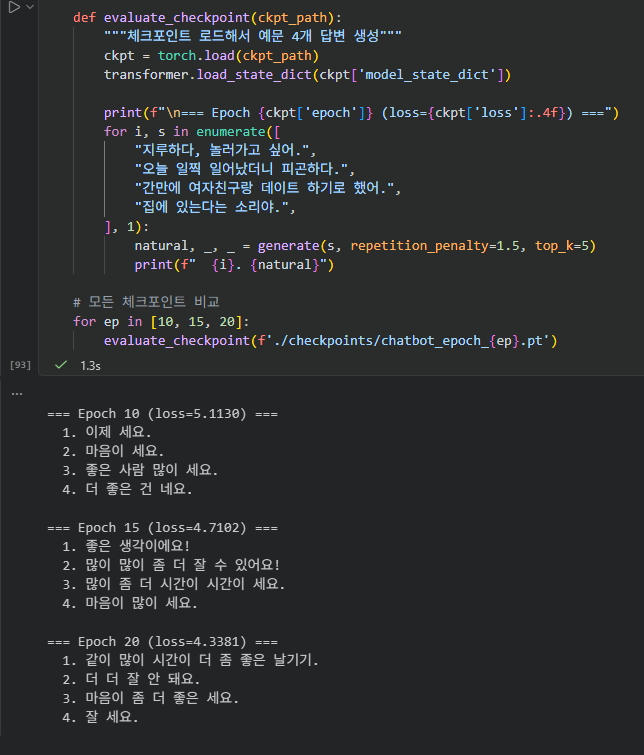

#### 아까 이거보고 어? 조금 괜찮게 나왔네 했는데 운빨이었다니..... 어떻게 개선해야할지 감도안와요.

## 회고

### 아~ 모르겠다

#### 